# Backtest 005d - TTM Breakout Squeeze + AVWAP Filter

Fork of `backtest_005.ipynb` with an Anchored VWAP filter added on top of the TTM breakout entries.

## Strategy logic

| Version | Entry condition |
|---------|----------------|
| **v1** | `no_squeeze` AND `TTM momentum > 0` |
| **v2** | `no_squeeze` AND `TTM momentum crossed above 0` (up to 3 bars look-back) |
| **v3** | Squeeze JUST released AND (`momentum > 0` OR `consecutive_neg > threshold`) OR Williams VIX Fix signal |

**AVWAP filter:** final entry must also satisfy `close > AVWAP(lowest).shift(1)`

**Exit:** ATR trailing stop (multiplier optimised via Optuna)

**Optimisation:** Multi-objective Optuna - maximise `Total Return (%)` and `Sortino Ratio`


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.vwap import avwap_func_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [2]:
REMOTE_HOST = 'http://192.168.1.3:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake …')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

# ── extract OHLCV DataFrames (dates × symbols) ────────────────────────────────
open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 197)  |  2016-06-06 00:00:00 → 2026-06-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-01,7.03,15.6,24.9,43.7,9.06,12.00,14.55,21.6,5.55,5.86,...,1844.54,59.1,12.4,26.95,3.14,62.9,31.20,19.85,65.3,8.83
2026-06-02,6.98,15.8,25.1,43.4,9.06,11.95,14.30,21.1,5.47,5.86,...,1826.47,58.6,12.2,26.45,3.04,61.9,31.00,19.25,65.7,9.04
2026-06-03,7.00,15.9,26.0,43.7,9.05,11.95,14.30,21.3,5.46,5.99,...,1819.01,58.3,12.3,26.45,3.01,60.5,30.05,19.65,65.8,9.01


## 2. TTM Breakout Helpers

In [3]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────

@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    """Shift a 2-D array along axis 0 (time axis)."""
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    """Count consecutive negative values per column (used for TTM momentum bars)."""
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    """
    Kaufman's Adaptive Moving Average applied column-wise.
    - Efficiency Ratio (ER) = |close - close[period]| / sum(|diff(close)|, period)
    - Smoothing Constant (SC) = (ER * (fast_sc - slow_sc) + slow_sc)^2
    - KAMA[i] = KAMA[i-1] + SC * (close[i] - KAMA[i-1])
    When market is trending (ER -> 1), SC -> fast_sc (tracks quickly).
    When market is choppy   (ER -> 0), SC -> slow_sc (barely moves).
    """
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    """
    Returns a boolean 2-D mask that is True where the KAMA line is
    'flat': |pct change over slope_window bars| < flat_threshold_pct.
    First slope_window rows are always False.
    """
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=np.bool_)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out

@nb.njit
def _early_exit_nb(close_2d, low_2d, entries_2d, window, pct):
    """
    For each symbol: after an entry, if the bar LOW drops > pct from entry close
    within the first `window` bars, emit an exit signal.
    Uses low (not close) so intraday wicks are captured as true MAE.
    """
    n_rows, n_cols = close_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar   = -1
        entry_close = np.nan
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar   = row
                entry_close = close_2d[row, col]
            if entry_bar >= 0:
                bars_since = row - entry_bar
                if 1 <= bars_since <= window:
                    mae = (entry_close - low_2d[row, col]) / entry_close
                    if mae > pct:
                        out[row, col] = True
                        entry_bar = -1   # stop watching after firing
    return out


def early_exit_signal(close, low, entries, window=5, pct=0.05):
    """Returns a boolean exit DataFrame: fires when MAE (low-based) > pct within `window` bars of entry."""
    result = _early_exit_nb(
        close.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        entries.to_numpy().astype(np.bool_),
        window, pct,
    )
    return pd.DataFrame(result, index=close.index, columns=close.columns)


@nb.njit
def _max_hold_exit_nb(entries_2d, max_hold_days):
    """Exit when bars held since last entry exceed max_hold_days."""
    n_rows, n_cols = entries_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar = -1
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar = row
            if entry_bar >= 0:
                if row - entry_bar > max_hold_days:
                    out[row, col] = True
                    entry_bar = -1
    return out


def max_hold_exit_signal(entries, max_hold_days=160):
    """Exit when position held longer than max_hold_days (daily bars)."""
    result = _max_hold_exit_nb(entries.to_numpy().astype(np.bool_), max_hold_days)
    return pd.DataFrame(result, index=entries.index, columns=entries.columns)


print('early_exit_signal defined (MAE = low-based)')
print('max_hold_exit_signal defined (>30d default)')

print('Numba helpers compiled')


early_exit_signal defined (MAE = low-based)
max_hold_exit_signal defined (>30d default)
Numba helpers compiled


In [4]:
AVWAP = vbt.IndicatorFactory(
    class_name='AVWAP',
    short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap'],
).from_apply_func(avwap_func_nb)

_avwap_lowest_cache = {}


def get_avwap_lowest(close, high, low, volume, window: int = 200):
    key = (id(close), id(high), id(low), id(volume), int(window))
    if key not in _avwap_lowest_cache:
        avwap = AVWAP.run(
            close, high, low, volume,
            is_highest=[False],
            window=int(window),
        ).avwap
        avwap_lowest = avwap.xs(False, level='avwap_is_highest', axis=1)
        avwap_lowest.columns = avwap_lowest.columns.get_level_values(-1)
        _avwap_lowest_cache[key] = avwap_lowest.reindex(columns=close.columns)
    return _avwap_lowest_cache[key]


def compute_signals(
    close, high, low, volume,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # AVWAP filter
    # use_avwap_filter:         bool  = True,
    # avwap_window:             int   = 200,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
    # Near-recent-low filter: close must be within max_pct of rolling min close
    use_near_low_filter:      bool  = True,
    near_low_window:          int   = 5,
    near_low_max_pct:         float = 10.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout - gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) - NOT gated
      v3 WVF    : volatility spike / contrarian - NOT gated

    Near-low filter (optional): at entry, (close - MIN(close, N)) / MIN(close, N)
      must be < near_low_max_pct — avoids buying too far above recent lows.

    AVWAP gate applies after the TTM logic:
      final entry must also satisfy close > AVWAP(lowest).shift(1)
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    MIN  = vbt.IndicatorFactory.from_talib('MIN')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # indicators -> numpy
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MIN.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    # if use_avwap_filter:
    #     avwap_lowest = get_avwap_lowest(close, high, low, volume, avwap_window)
    #     avwap_prev_np = shift_2d(avwap_lowest.to_numpy(dtype=np.float64), 1)
    #     avwap_filter_np = (close_np > avwap_prev_np) & (~np.isnan(avwap_prev_np))
    # else:
    #     avwap_filter_np = np.ones_like(close_np, dtype=np.bool_)

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    else:
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period,
            mult=bb_multiplier,
            bbl=bb_window,
            lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()
        entries_np =  wvf_np

    # entries_np = entries_np # & avwap_filter_np

    if use_near_low_filter:
        min_close_np = MIN.run(close, timeperiod=near_low_window).real.to_numpy()
        pct_above_low = (close_np - min_close_np) / min_close_np * 100.0
        near_low_np = (
            np.isfinite(pct_above_low)
            & (min_close_np > 0)
            & (pct_above_low < near_low_max_pct)
        )
        entries_np = entries_np & near_low_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5, entries=None, max_hold_days=30):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings; if ``entries`` is given, also exits
                when hold time exceeds ``max_hold_days`` (default 30 daily bars).
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    if entries is not None and max_hold_days is not None:
        exits_df = exits_df | max_hold_exit_signal(entries, max_hold_days=max_hold_days)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


In [5]:
# ── Chandelier Exit (port of the Pine Script reference) ───────────────────────
# Pine logic:
#   atr         = ta.atr(length)                              # Wilder ATR
#   highestHigh = avg(highest(close, length), highest(high, length))
#   lowestLow   = avg(lowest (close, length), lowest (low,  length))
#   chandLong   = highestHigh - atr*mult
#   chandShort  = lowestLow   + atr*mult
#   dir         = close>chandShort ? 1 : close<chandLong ? -1 : dir[prev]
#   chandExit   = dir>0 ? chandLong : chandShort
# We exit a LONG when dir flips +1 -> -1 (close breaks below the long trail).

@nb.njit(cache=True)
def _chandelier_nb(close, high, low, atr, multiplier, length):
    n, m = close.shape
    chand     = np.full((n, m), np.nan)
    direction = np.zeros((n, m), dtype=np.int64)
    for col in range(m):
        d = 1
        for i in range(n):
            c = close[i, col]
            a = atr[i, col]
            if np.isnan(c) or np.isnan(a) or i < length - 1:
                direction[i, col] = d
                continue
            hc = -1e18; hh = -1e18; lc = 1e18; ll = 1e18
            for k in range(i - length + 1, i + 1):
                cc = close[k, col]; hk = high[k, col]; lk = low[k, col]
                if cc > hc: hc = cc
                if hk > hh: hh = hk
                if cc < lc: lc = cc
                if lk < ll: ll = lk
            highest_high = 0.5 * (hc + hh)
            lowest_low   = 0.5 * (lc + ll)
            chand_long  = highest_high - a * multiplier
            chand_short = lowest_low   + a * multiplier
            if c > chand_short:
                d = 1
            elif c < chand_long:
                d = -1
            direction[i, col] = d
            chand[i, col] = chand_long if d > 0 else chand_short
    return chand, direction


def compute_exits_chandelier(close, high, low, length=5, multiplier=2.2,
                             entries=None, max_hold_days=30, low_stop_lookback=5,
                             return_line=False):
    """
    Chandelier trailing-stop exits. Drop-in alternative to ``compute_exits``.

    Returns (exits_df, sl_stop_df) — same shape/contract as ``compute_exits`` so it
    can be swapped directly in ``vbt.Portfolio.from_signals``. The swing-low
    ``sl_stop_df`` (initial hard stop) is kept identical to ``compute_exits`` so an
    A/B test isolates ONLY the trailing mechanism.

    With return_line=True also returns (line_df, dir_df) for plotting/inspection.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=length
    ).real
    chand, direction = _chandelier_nb(
        close.to_numpy().astype(np.float64),
        high.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        atr_raw.to_numpy().astype(np.float64),
        float(multiplier), int(length),
    )
    dir_df  = pd.DataFrame(direction, index=close.index, columns=close.columns)
    line_df = pd.DataFrame(chand,     index=close.index, columns=close.columns)

    # Exit when the directional state flips long -> short.
    exits_df = (dir_df == -1) & (dir_df.shift(1) == 1)

    if entries is not None and max_hold_days is not None:
        exits_df = exits_df | max_hold_exit_signal(entries, max_hold_days=max_hold_days)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    if return_line:
        return exits_df, sl_stop_df, line_df, dir_df
    return exits_df, sl_stop_df


print('Chandelier exit defined (compute_exits_chandelier)')


Chandelier exit defined (compute_exits_chandelier)


## 3. Baseline Run (default params, entry v3)

In [6]:
print('Computing baseline signals (v3, default params + AVWAP filter) ...')
entries_base = compute_signals(
    close, high, low, volume,
    bb_window=16, bb_multiplier=1.0, bb_matype=3,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3',
    consecutive_neg_threshold=7,
    william_vix_period=20,
)
exits_base, sl_stop_base = compute_exits_chandelier(
    close, high, low, length=22, multiplier=3.0,
)

print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base,
    exits=exits_base,
    sl_stop=sl_stop_base,
    freq='1d',
    group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)


Computing baseline signals (v3, default params + AVWAP filter) ...
Entry signals: 10,950

Baseline portfolio stats:


Start                                  2016-06-06 00:00:00
End                                    2026-06-03 00:00:00
Period                                  2499 days 00:00:00
Start Value                                          100.0
End Value                                       243.707505
Total Return [%]                                143.707505
Benchmark Return [%]                            277.366621
Max Gross Exposure [%]                               100.0
Total Fees Paid                                        0.0
Max Drawdown [%]                                 48.195532
Max Drawdown Duration         1039 days 09:59:23.451776656
Total Trades                                     41.461929
Total Closed Trades                              41.040609
Total Open Trades                                  0.42132
Open Trade PnL                                    1.998437
Win Rate [%]                                     35.521264
Best Trade [%]                                   78.3947

## 4. Per-Version Optimisation - v1, v2, v3 Separate Studies

Each version gets its own Optuna study so parameter spaces can be tuned
independently. `005d` adds `avwap_window` on top of the original `005` search space.

| Study | Entry logic | Extra params |
|-------|------------|--------------|
| `study_v1` | `no_squeeze & TTM > 0`, then AVWAP filter | `avwap_window` |
| `study_v2` | `no_squeeze & TTM crossed above 0` (+/-2 bars), then AVWAP filter | `avwap_window` |
| `study_v3` | squeeze released & (`TTM>0` OR `consec_neg>thr`) OR WVF, then AVWAP filter | `consecutive_neg_threshold`, `william_vix_period`, `avwap_window` |


In [7]:
def make_objective(version: str):
    """
    Returns an Optuna objective function fixed to `version`.
    Objectives: (Total Return %, Sortino Ratio)
    Exit: Chandelier (length, multiplier optimised jointly with entry params).
    """
    def objective(trial):
        bb_window            = trial.suggest_int  ('bb_window',           10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',       0.8, 2.0, step=0.1)
        bb_matype            = trial.suggest_int  ('bb_matype',           0, 3)

        kc_window            = trial.suggest_int  ('kc_window',           20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',       0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',       5, 20)
        donichan_window      = 10
        osc_smoothing_period = 5

        chand_length         = trial.suggest_int  ('chand_length',        10, 40)
        chand_mult           = trial.suggest_float('chand_mult',          1.5, 5.0, step=0.1)
        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',   3, 20)

        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',       14, 30)

        kama_period        = trial.suggest_int  ('kama_period',        5, 20)
        kama_fast          = trial.suggest_int  ('kama_fast',          2, 5)
        kama_slow          = trial.suggest_int  ('kama_slow',          20, 50)
        kama_slope_win     = trial.suggest_int  ('kama_slope_win',     3, 20)
        flat_threshold_pct = trial.suggest_float('flat_threshold_pct', 1, 3.0, step=0.1)

        try:
            entries = compute_signals(
                close, high, low, volume,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=bb_matype,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period,
                donichan_window=donichan_window,
                osc_smoothing_period=osc_smoothing_period,
                entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
                use_kama_slope=True,
                kama_period=kama_period,
                kama_fast=kama_fast,
                kama_slow=kama_slow,
                kama_slope_win=kama_slope_win,
                flat_threshold_pct=flat_threshold_pct,
            )
            exits, sl_stop_df = compute_exits_chandelier(
                close, high, low,
                length=chand_length, multiplier=chand_mult,
                low_stop_lookback=low_stop_lookback,
                entries=entries,
            )

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )

            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()

            if len(total_ret) == 0:
                return -999.0, -999.0

            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0

            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5

            return mean_ret, mean_sort

        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 1000   # raise for better coverage

studies = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n-- Optimising {ver} ({N_TRIALS_PER_VERSION} trials) ----------------------')
    s = optuna.create_study(
        directions   = ['maximize', 'maximize'],
        study_name   = f'ttm_chandelier_{ver}',
        sampler      = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')



-- Optimising v1 (1000 trials) ----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 4 trials

-- Optimising v2 (1000 trials) ----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 6 trials

-- Optimising v3 (1000 trials) ----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 15 trials

All studies done.


## 4b. Walk-Forward Validation (WFV)

Prevents overfitting by optimising on a **rolling train window** then evaluating on the
next unseen **test window**.

| Setting | Value |
|---------|-------|
| Train window | `WFV_TRAIN_YEARS` years |
| Test window  | `WFV_TEST_MONTHS` months |
| Step         | `WFV_STEP_MONTHS` months |
| Trials / fold| `WFV_N_TRIALS` |

Outputs after all folds:
- Per-fold IS vs OOS return / Sortino chart
- Param stability table (mean ± std, CV%)
- **Recommended params** = median across folds (stored in `wfv_best_params`)


In [8]:
# ─── WFV config ───────────────────────────────────────────────────────────────
WFV_TRAIN_YEARS  = 2
WFV_TEST_MONTHS  = 6
WFV_STEP_MONTHS  = 6
WFV_N_TRIALS     = 150
WFV_VERSIONS     = ['v1', 'v2', 'v3']


def build_wfv_windows(index, train_years=WFV_TRAIN_YEARS,
                      test_months=WFV_TEST_MONTHS, step_months=WFV_STEP_MONTHS):
    windows = []
    test_start = index[0] + pd.DateOffset(years=train_years)
    end = index[-1]
    while test_start + pd.DateOffset(months=test_months) <= end:
        tr_s = test_start - pd.DateOffset(years=train_years)
        tr_e = test_start - pd.Timedelta(days=1)
        te_s = test_start
        te_e = min(
            test_start + pd.DateOffset(months=test_months) - pd.Timedelta(days=1),
            end,
        )
        windows.append((tr_s, tr_e, te_s, te_e))
        test_start += pd.DateOffset(months=step_months)
    return windows


def make_wfv_objective(version, c, h, l, v):
    """Optuna objective using sliced data and Chandelier exit."""
    def objective(trial):
        bb_window            = trial.suggest_int  ('bb_window',            10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',        0.8, 2.0, step=0.1)
        bb_matype            = trial.suggest_int  ('bb_matype',            0, 3)
        kc_window            = trial.suggest_int  ('kc_window',            20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',        0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',        5, 20)
        chand_length         = trial.suggest_int  ('chand_length',         10, 40)
        chand_mult           = trial.suggest_float('chand_mult',           1.5, 5.0, step=0.1)
        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',    3, 20)
        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',        14, 30)
        kama_period        = trial.suggest_int  ('kama_period',         5, 20)
        kama_fast          = trial.suggest_int  ('kama_fast',           2, 5)
        kama_slow          = trial.suggest_int  ('kama_slow',           20, 50)
        kama_slope_win     = trial.suggest_int  ('kama_slope_win',      3, 20)
        flat_threshold_pct = trial.suggest_float('flat_threshold_pct',  1.0, 3.0, step=0.1)
        try:
            entries = compute_signals(
                c, h, l, v,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=bb_matype,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period, donichan_window=10,
                osc_smoothing_period=5, entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
                use_kama_slope=True,
                kama_period=kama_period, kama_fast=kama_fast,
                kama_slow=kama_slow, kama_slope_win=kama_slope_win,
                flat_threshold_pct=flat_threshold_pct,
            )
            exits, sl_stop_df = compute_exits_chandelier(
                c, h, l,
                length=chand_length, multiplier=chand_mult,
                low_stop_lookback=low_stop_lookback, entries=entries,
            )
            pf = vbt.Portfolio.from_signals(
                close=c, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )
            tot = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            srt = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            shr = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            if len(tot) == 0:
                return -999.0, -999.0
            mr = float(tot.mean() * 100)
            ms = float(srt.mean()) if len(srt) > 0 else -999.0
            if len(shr) > 0 and (shr > 0).mean() < 0.3:
                mr *= 0.5
                ms *= 0.5
            return mr, ms
        except Exception:
            return -999.0, -999.0
    return objective


def _eval_oos(version, params, c, h, l, v):
    """Evaluate params on OOS slice; returns (total_return_pct, sortino, sharpe)."""
    p = params
    try:
        entries = compute_signals(
            c, h, l, v,
            bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
            bb_matype=p['bb_matype'], kc_window=p['kc_window'],
            kc_multiplier=p['kc_multiplier'], kc_atr_period=p['kc_atr_period'],
            donichan_window=p.get('donichan_window', 10),
            osc_smoothing_period=p.get('osc_smoothing_period', 5),
            entry_version=version,
            consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
            william_vix_period=p.get('william_vix_period', 20),
            use_kama_slope=True,
            kama_period=p.get('kama_period', 10),
            kama_fast=p.get('kama_fast', 2),
            kama_slow=p.get('kama_slow', 30),
            kama_slope_win=p.get('kama_slope_win', 5),
            flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
        )
        exits, sl_df = compute_exits_chandelier(
            c, h, l,
            length=p.get('chand_length', 22),
            multiplier=p.get('chand_mult', 3.0),
            low_stop_lookback=p.get('low_stop_lookback', 5),
            entries=entries,
        )
        pf = vbt.Portfolio.from_signals(
            close=c, entries=entries, exits=exits,
            freq='1d', group_by=['symbol'],
            cash_sharing=False, sl_stop=sl_df,
        )
        r  = float(pf.total_return().replace([np.inf, -np.inf], np.nan).dropna().mean() * 100)
        so = float(pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna().mean())
        sh = float(pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().mean())
        return r, so, sh
    except Exception:
        return float('nan'), float('nan'), float('nan')


def _wfv_pick_best(study, selection='balanced'):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

print('WFV helpers defined (Chandelier exit).')
_wins = build_wfv_windows(close.index)
print(f'{len(_wins)} WFV folds  |  train={WFV_TRAIN_YEARS}yr  test={WFV_TEST_MONTHS}mo  step={WFV_STEP_MONTHS}mo')
for i, (a, b, c_, d) in enumerate(_wins):
    print(f'  Fold {i+1:2d}: train {a.date()} -> {b.date()}  |  test {c_.date()} -> {d.date()}')


WFV helpers defined (Chandelier exit).
15 WFV folds  |  train=2yr  test=6mo  step=6mo
  Fold  1: train 2016-06-06 -> 2018-06-05  |  test 2018-06-06 -> 2018-12-05
  Fold  2: train 2016-12-06 -> 2018-12-05  |  test 2018-12-06 -> 2019-06-05
  Fold  3: train 2017-06-06 -> 2019-06-05  |  test 2019-06-06 -> 2019-12-05
  Fold  4: train 2017-12-06 -> 2019-12-05  |  test 2019-12-06 -> 2020-06-05
  Fold  5: train 2018-06-06 -> 2020-06-05  |  test 2020-06-06 -> 2020-12-05
  Fold  6: train 2018-12-06 -> 2020-12-05  |  test 2020-12-06 -> 2021-06-05
  Fold  7: train 2019-06-06 -> 2021-06-05  |  test 2021-06-06 -> 2021-12-05
  Fold  8: train 2019-12-06 -> 2021-12-05  |  test 2021-12-06 -> 2022-06-05
  Fold  9: train 2020-06-06 -> 2022-06-05  |  test 2022-06-06 -> 2022-12-05
  Fold 10: train 2020-12-06 -> 2022-12-05  |  test 2022-12-06 -> 2023-06-05
  Fold 11: train 2021-06-06 -> 2023-06-05  |  test 2023-06-06 -> 2023-12-05
  Fold 12: train 2021-12-06 -> 2023-12-05  |  test 2023-12-06 -> 2024-06-05
  

In [9]:
# ─── Run Walk-Forward Validation ──────────────────────────────────────────────
# SLOW: O(n_folds * n_versions * WFV_N_TRIALS) full backtests.
# Quick smoke-test: set WFV_N_TRIALS = 50.

wfv_windows = build_wfv_windows(close.index)
wfv_records = []   # one row per (version, fold)

for ver in WFV_VERSIONS:
    print(f'\n{"="*60}')
    print(f'  Walk-Forward: {ver}  ({len(wfv_windows)} folds x {WFV_N_TRIALS} trials)')
    print(f'{"="*60}')

    for i, (tr_s, tr_e, te_s, te_e) in enumerate(wfv_windows):
        print(
            f'  fold {i+1:2d}/{len(wfv_windows)}'
            f'  train {tr_s.date()} -> {tr_e.date()}'
            f'  test {te_s.date()} -> {te_e.date()}',
            end=' ... ',
        )

        tr_mask = (close.index >= tr_s) & (close.index <= tr_e)
        te_mask = (close.index >= te_s) & (close.index <= te_e)
        c_tr, h_tr = close[tr_mask], high[tr_mask]
        l_tr, v_tr = low[tr_mask],   volume[tr_mask]
        c_te, h_te = close[te_mask], high[te_mask]
        l_te, v_te = low[te_mask],   volume[te_mask]

        study_wfv = optuna.create_study(
            directions=['maximize', 'maximize'],
            sampler=optuna.samplers.NSGAIISampler(seed=42),
        )
        study_wfv.optimize(
            make_wfv_objective(ver, c_tr, h_tr, l_tr, v_tr),
            n_trials=WFV_N_TRIALS,
            show_progress_bar=False,
        )

        best_t  = _wfv_pick_best(study_wfv)
        p_best  = best_t.params
        is_ret  = best_t.values[0]
        is_sort = best_t.values[1]

        oos_ret, oos_sort, oos_sharpe = _eval_oos(ver, p_best, c_te, h_te, l_te, v_te)
        print(f'IS ret={is_ret:.1f}%  OOS ret={oos_ret:.1f}%  OOS sharpe={oos_sharpe:.2f}')

        rec = {
            'version': ver, 'fold': i + 1,
            'train_start': tr_s, 'train_end': tr_e,
            'test_start':  te_s, 'test_end':  te_e,
            'is_return':   is_ret,  'is_sortino': is_sort,
            'oos_return':  oos_ret, 'oos_sortino': oos_sort, 'oos_sharpe': oos_sharpe,
        }
        rec.update({f'p_{k}': v for k, v in p_best.items()})
        wfv_records.append(rec)

wfv_df = pd.DataFrame(wfv_records)
print('\nWFV complete.')
display(wfv_df[['version', 'fold', 'test_start', 'is_return', 'oos_return', 'oos_sortino', 'oos_sharpe']])



  Walk-Forward: v1  (15 folds x 150 trials)
  fold  1/15  train 2016-06-06 -> 2018-06-05  test 2018-06-06 -> 2018-12-05 ... IS ret=8.2%  OOS ret=3.0%  OOS sharpe=0.09
  fold  2/15  train 2016-12-06 -> 2018-12-05  test 2018-12-06 -> 2019-06-05 ... IS ret=33.7%  OOS ret=4.9%  OOS sharpe=0.27
  fold  3/15  train 2017-06-06 -> 2019-06-05  test 2019-06-06 -> 2019-12-05 ... IS ret=17.3%  OOS ret=-0.9%  OOS sharpe=-0.38
  fold  4/15  train 2017-12-06 -> 2019-12-05  test 2019-12-06 -> 2020-06-05 ... IS ret=7.8%  OOS ret=5.9%  OOS sharpe=0.11
  fold  5/15  train 2018-06-06 -> 2020-06-05  test 2020-06-06 -> 2020-12-05 ... IS ret=25.4%  OOS ret=20.7%  OOS sharpe=1.30
  fold  6/15  train 2018-12-06 -> 2020-12-05  test 2020-12-06 -> 2021-06-05 ... IS ret=7.7%  OOS ret=6.4%  OOS sharpe=0.36
  fold  7/15  train 2019-06-06 -> 2021-06-05  test 2021-06-06 -> 2021-12-05 ... IS ret=23.3%  OOS ret=17.2%  OOS sharpe=1.15
  fold  8/15  train 2019-12-06 -> 2021-12-05  test 2021-12-06 -> 2022-06-05 ... IS ret

,version,fold,test_start,is_return,oos_return,oos_sortino,oos_sharpe
0,v1,1,2018-06-06,8.232486,3.043139,7.632507e-01,0.091724
1,v1,2,2018-12-06,33.741683,4.873037,6.855951e-01,0.269976
2,v1,3,2019-06-06,17.252308,-0.850304,-2.300194e-01,-0.377572
3,v1,4,2019-12-06,7.831283,5.938005,1.016397e+00,0.109980
4,v1,5,2020-06-06,25.393438,20.735196,2.619302e+00,1.297139
5,v1,6,2020-12-06,7.722982,6.359670,3.476285e+00,0.362712
6,v1,7,2021-06-06,23.292285,17.182965,2.678219e+00,1.153367
7,v1,8,2021-12-06,40.122460,-1.394186,-8.910200e-02,-0.785914
8,v1,9,2022-06-06,167.274810,10.110523,1.411784e+00,0.698947
9,v1,10,2022-12-06,32.642754,16.390376,2.007694e+00,1.029116


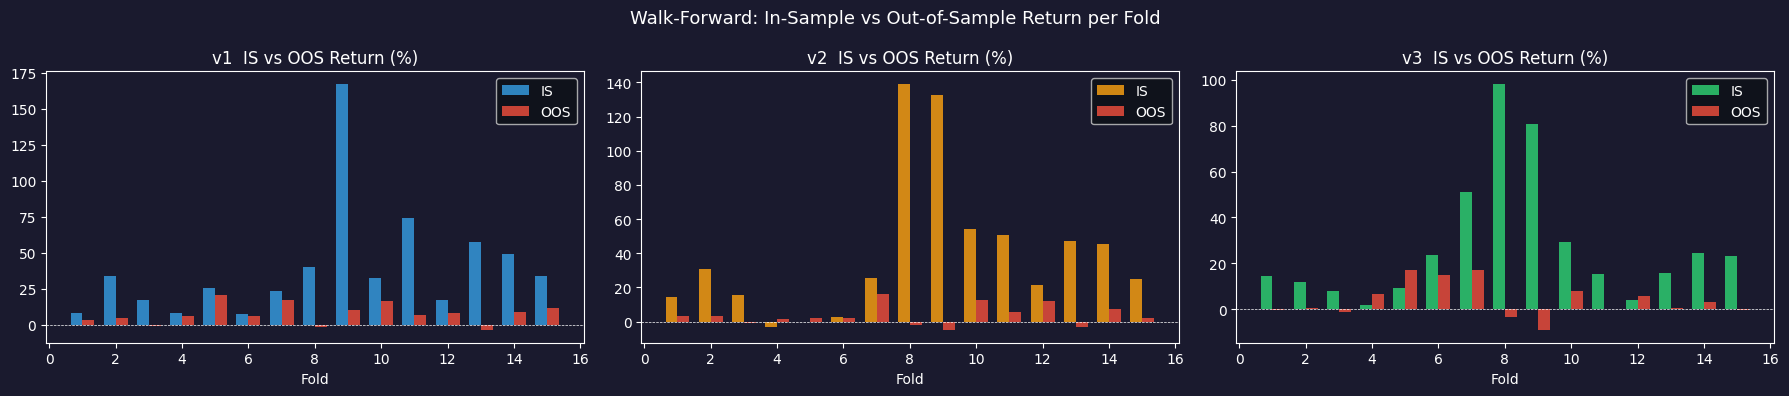

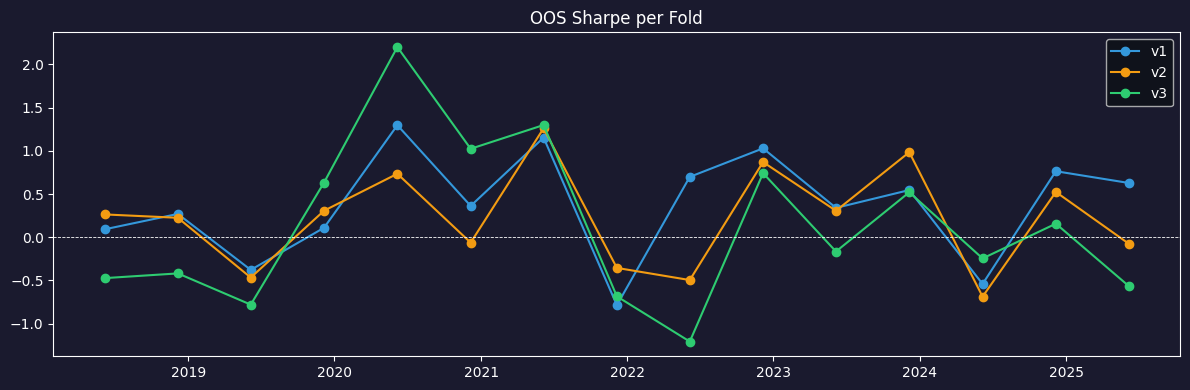


--- Param Stability (mean +/- std across folds) ---

  v1:


,mean,std,cv%
bb_window,17.20,4.65,27.0
bb_multiplier,1.33,0.36,27.1
bb_matype,1.07,0.96,90.1
kc_window,36.40,9.01,24.8
kc_multiplier,1.17,0.31,26.7
kc_atr_period,16.33,4.45,27.2
chand_length,34.40,5.72,16.6
chand_mult,2.49,0.56,22.4
low_stop_lookback,8.27,4.50,54.4
consecutive_neg_threshold,8.93,3.47,38.9



  v2:


,mean,std,cv%
bb_window,14.07,4.79,34.0
bb_multiplier,1.57,0.27,16.9
bb_matype,1.80,0.86,47.9
kc_window,41.87,11.12,26.5
kc_multiplier,1.30,0.38,29.1
kc_atr_period,14.67,5.22,35.6
chand_length,29.87,7.97,26.7
chand_mult,3.11,0.87,27.9
low_stop_lookback,10.80,5.51,51.0
consecutive_neg_threshold,10.73,2.79,26.0



  v3:


,mean,std,cv%
bb_window,16.07,5.08,31.6
bb_multiplier,1.11,0.38,33.9
bb_matype,1.27,1.10,86.8
kc_window,37.00,11.57,31.3
kc_multiplier,1.18,0.43,36.7
kc_atr_period,13.47,4.21,31.2
chand_length,26.20,8.36,31.9
chand_mult,3.37,1.08,31.9
low_stop_lookback,11.13,5.38,48.4
consecutive_neg_threshold,8.27,2.91,35.3



--- Recommended Params (median across WFV folds) ---
  v1: {'bb_window': 18, 'bb_multiplier': 1.2, 'bb_matype': 1, 'kc_window': 38, 'kc_multiplier': 1.1, 'kc_atr_period': 17, 'chand_length': 38, 'chand_mult': 2.3, 'low_stop_lookback': 9, 'consecutive_neg_threshold': 9, 'william_vix_period': 19, 'kama_period': 13, 'kama_fast': 4, 'kama_slow': 33, 'kama_slope_win': 7, 'flat_threshold_pct': 2.5}
  v2: {'bb_window': 12, 'bb_multiplier': 1.7, 'bb_matype': 2, 'kc_window': 47, 'kc_multiplier': 1.3, 'kc_atr_period': 17, 'chand_length': 33, 'chand_mult': 3.2, 'low_stop_lookback': 8, 'consecutive_neg_threshold': 10, 'william_vix_period': 20, 'kama_period': 16, 'kama_fast': 4, 'kama_slow': 37, 'kama_slope_win': 6, 'flat_threshold_pct': 2.5}
  v3: {'bb_window': 19, 'bb_multiplier': 1.0, 'bb_matype': 1, 'kc_window': 35, 'kc_multiplier': 0.9, 'kc_atr_period': 14, 'chand_length': 28, 'chand_mult': 3.7, 'low_stop_lookback': 11, 'consecutive_neg_threshold': 9, 'william_vix_period': 17, 'kama_period': 

,folds,oos_ret_mean,oos_ret_pos%,oos_sortino_mean,oos_sharpe_mean,is_ret_mean,overfit_ratio
version,,,,,,,
v1,15,7.56,80.0,1.254000e+00,0.373,39.65,0.191
v2,15,3.73,73.3,5.844473e+11,0.223,40.06,0.093
v3,15,3.93,66.7,6.313101e+10,0.136,27.42,0.143



overfit_ratio: OOS/IS return -- closer to 1.0 = less overfit.


In [10]:
# ─── WFV Analysis ─────────────────────────────────────────────────────────────

COLORS_WFV = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

# 1. IS vs OOS return per fold
fig, axes = plt.subplots(1, len(WFV_VERSIONS),
                         figsize=(6 * len(WFV_VERSIONS), 4), sharey=False)
fig.patch.set_facecolor('#1a1a2e')
if len(WFV_VERSIONS) == 1:
    axes = [axes]

for ax, ver in zip(axes, WFV_VERSIONS):
    sub = wfv_df[wfv_df['version'] == ver].copy()
    x = sub['fold']
    ax.bar(x - 0.18, sub['is_return'],  width=0.36, color=COLORS_WFV[ver], alpha=0.85, label='IS')
    ax.bar(x + 0.18, sub['oos_return'], width=0.36, color='#e74c3c',        alpha=0.85, label='OOS')
    ax.axhline(0, color='white', lw=0.5, ls='--')
    ax.set_facecolor('#1a1a2e')
    ax.set_title(f'{ver}  IS vs OOS Return (%)', color='white')
    ax.tick_params(colors='white')
    [sp.set_edgecolor('white') for sp in ax.spines.values()]
    ax.legend(facecolor='#0d1117', labelcolor='white')
    ax.set_xlabel('Fold', color='white')

plt.suptitle('Walk-Forward: In-Sample vs Out-of-Sample Return per Fold',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

# 2. OOS Sharpe over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver].sort_values('fold')
    ax.plot(sub['test_start'], sub['oos_sharpe'],
            marker='o', color=COLORS_WFV[ver], label=ver, lw=1.5)
ax.axhline(0, color='white', lw=0.6, ls='--')
ax.set_title('OOS Sharpe per Fold', color='white')
ax.tick_params(colors='white')
[sp.set_edgecolor('white') for sp in ax.spines.values()]
ax.legend(facecolor='#0d1117', labelcolor='white')
plt.tight_layout()
plt.show()

# 3. Param stability
print('\n--- Param Stability (mean +/- std across folds) ---')
param_cols_wfv = [c for c in wfv_df.columns if c.startswith('p_')]
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver][param_cols_wfv]
    stats = sub.agg(['mean', 'std']).T
    stats.columns = ['mean', 'std']
    stats['cv%'] = (stats['std'] / stats['mean'].abs() * 100).round(1)
    stats.index = [c[2:] for c in stats.index]
    print(f'\n  {ver}:')
    display(stats.style.format({'mean': '{:.2f}', 'std': '{:.2f}', 'cv%': '{:.1f}'}))

# 4. Recommended params = median across folds
print('\n--- Recommended Params (median across WFV folds) ---')
INT_PARAMS = {
    'bb_window', 'bb_matype', 'kc_window', 'kc_atr_period',
    'chand_length', 'low_stop_lookback', 'consecutive_neg_threshold',
    'william_vix_period', 'kama_period', 'kama_fast', 'kama_slow', 'kama_slope_win',
}
wfv_best_params = {}
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver][param_cols_wfv]
    med = sub.median().to_dict()
    med = {k[2:]: (int(round(v)) if k[2:] in INT_PARAMS else round(v, 2))
           for k, v in med.items()}
    wfv_best_params[ver] = med
    print(f'  {ver}: {med}')

# 5. Summary
print('\n--- WFV Summary ---')
summary_wfv = []
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver]
    is_mean = sub['is_return'].mean()
    summary_wfv.append({
        'version':          ver,
        'folds':            len(sub),
        'oos_ret_mean':     round(sub['oos_return'].mean(), 2),
        'oos_ret_pos%':     round((sub['oos_return'] > 0).mean() * 100, 1),
        'oos_sortino_mean': round(sub['oos_sortino'].mean(), 3),
        'oos_sharpe_mean':  round(sub['oos_sharpe'].mean(), 3),
        'is_ret_mean':      round(is_mean, 2),
        'overfit_ratio':    round(sub['oos_return'].mean() / is_mean, 3)
                            if is_mean != 0 else float('nan'),
    })
display(pd.DataFrame(summary_wfv).set_index('version'))
print('\noverfit_ratio: OOS/IS return -- closer to 1.0 = less overfit.')


## 5. Select Best Params per Version

In [11]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    # balanced
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trials = {ver: pick_best(studies[ver]) for ver in ['v1', 'v2', 'v3']}
best_params = {ver: t.params for ver, t in best_trials.items()}

summary_rows = []
for ver, trial in best_trials.items():
    row = {'Version': ver,
           'Trial #': trial.number,
           'Total Return (%)': round(trial.values[0], 2),
           'Sortino':          round(trial.values[1], 3)}
    row.update(trial.params)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Version')
print(f'Selection strategy: {SELECTION}')
display(summary_df)


Selection strategy: balanced


,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,bb_matype,kc_window,kc_multiplier,kc_atr_period,chand_length,chand_mult,low_stop_lookback,consecutive_neg_threshold,william_vix_period,kama_period,kama_fast,kama_slow,kama_slope_win,flat_threshold_pct
Version,,,,,,,,,,,,,,,,,,,
v1,947,511.15,1.134,10,1.2,3,49,0.8,6,31,2.2,3,5,15,7,3,28,6,2.3
v2,952,373.18,1.008,11,1.5,0,53,0.8,9,31,2.3,7,8,24,7,3,26,5,1.7
v3,856,150.24,0.706,12,1.9,1,29,1.5,16,12,3.9,20,7,18,16,2,20,19,2.3


In [12]:
# Extract all optimised parameters from `summary_df` (run after optimisation cell above)
_meta_cols = {'Trial #', 'Total Return (%)', 'Sortino'}
param_cols = [c for c in summary_df.columns if c not in _meta_cols]
all_params_by_version = summary_df[param_cols].to_dict('index')

import json
print('Tunable keys ({}):'.format(len(param_cols)))
print(param_cols)
print(json.dumps(all_params_by_version, indent=2, default=str))


Tunable keys (16):
['bb_window', 'bb_multiplier', 'bb_matype', 'kc_window', 'kc_multiplier', 'kc_atr_period', 'chand_length', 'chand_mult', 'low_stop_lookback', 'consecutive_neg_threshold', 'william_vix_period', 'kama_period', 'kama_fast', 'kama_slow', 'kama_slope_win', 'flat_threshold_pct']
{
  "v1": {
    "bb_window": 10,
    "bb_multiplier": 1.2000000000000002,
    "bb_matype": 3,
    "kc_window": 49,
    "kc_multiplier": 0.8,
    "kc_atr_period": 6,
    "chand_length": 31,
    "chand_mult": 2.2,
    "low_stop_lookback": 3,
    "consecutive_neg_threshold": 5,
    "william_vix_period": 15,
    "kama_period": 7,
    "kama_fast": 3,
    "kama_slow": 28,
    "kama_slope_win": 6,
    "flat_threshold_pct": 2.3
  },
  "v2": {
    "bb_window": 11,
    "bb_multiplier": 1.5,
    "bb_matype": 0,
    "kc_window": 53,
    "kc_multiplier": 0.8,
    "kc_atr_period": 9,
    "chand_length": 31,
    "chand_mult": 2.3,
    "low_stop_lookback": 7,
    "consecutive_neg_threshold": 8,
    "william_vix_pe

In [13]:
summary_df

,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,bb_matype,kc_window,kc_multiplier,kc_atr_period,chand_length,chand_mult,low_stop_lookback,consecutive_neg_threshold,william_vix_period,kama_period,kama_fast,kama_slow,kama_slope_win,flat_threshold_pct
Version,,,,,,,,,,,,,,,,,,,
v1,947,511.15,1.134,10,1.2,3,49,0.8,6,31,2.2,3,5,15,7,3,28,6,2.3
v2,952,373.18,1.008,11,1.5,0,53,0.8,9,31,2.3,7,8,24,7,3,26,5,1.7
v3,856,150.24,0.706,12,1.9,1,29,1.5,16,12,3.9,20,7,18,16,2,20,19,2.3


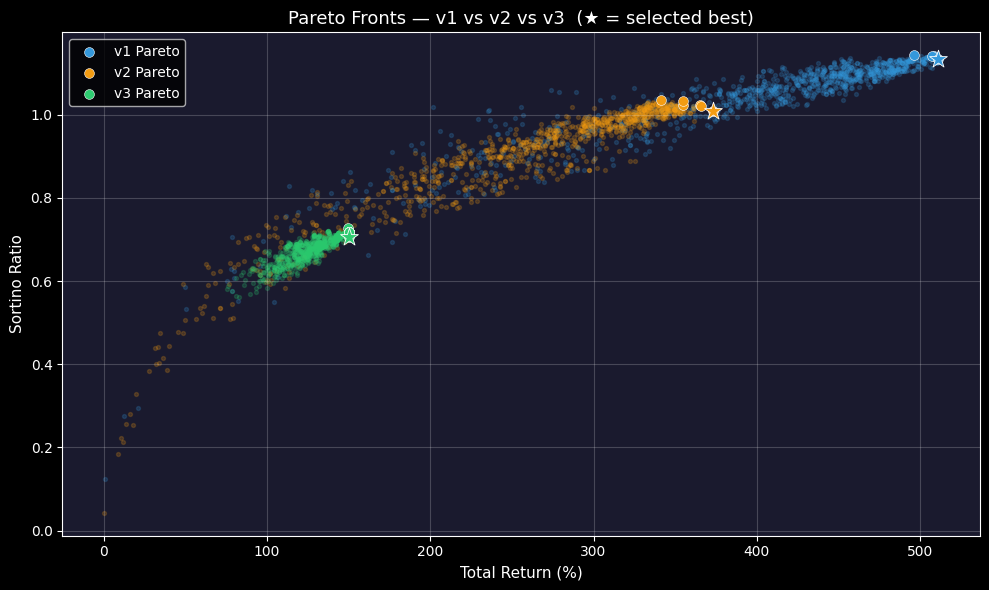

In [14]:
# ── Pareto fronts of all 3 versions on one chart ─────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

for ver, study in studies.items():
    col = COLORS[ver]
    # background: all trials
    all_vals = [(t.values[0], t.values[1]) for t in study.trials
                if t.values and t.values[0] > -900]
    if all_vals:
        ax.scatter(*zip(*all_vals), c=col, s=8, alpha=0.2)
    # Pareto front
    pf_vals = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter(*zip(*pf_vals), c=col, s=50, zorder=5,
               edgecolors='white', linewidths=0.4, label=f'{ver} Pareto')
    # best point
    bt = best_trials[ver]
    ax.scatter(bt.values[0], bt.values[1], c=col, s=180, marker='*',
               zorder=6, edgecolors='white', linewidths=0.6)

ax.set_xlabel('Total Return (%)', fontsize=11)
ax.set_ylabel('Sortino Ratio',    fontsize=11)
ax.set_title('Pareto Fronts — v1 vs v2 vs v3  (★ = selected best)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


## 6. Final Backtest — Optimised v1 vs v2 vs v3

In [15]:
portfolios = {}

for ver in ['v1', 'v2', 'v3']:
    p  = best_params[ver]
    print(f'Running optimised {ver} (Chandelier exit) ...')
    entries = compute_signals(
        close, high, low, volume,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = p['bb_matype'],
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p.get('donichan_window', 10),
        osc_smoothing_period     = p.get('osc_smoothing_period', 5),
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period', 20),
        use_kama_slope           = True,
        kama_period              = p.get('kama_period', 10),
        kama_fast                = p.get('kama_fast', 2),
        kama_slow                = p.get('kama_slow', 30),
        kama_slope_win           = p.get('kama_slope_win', 5),
        flat_threshold_pct       = p.get('flat_threshold_pct', 1.0),
        use_near_low_filter      = p.get('use_near_low_filter', False),
        near_low_window          = p.get('near_low_window', 3),
        near_low_max_pct         = p.get('near_low_max_pct', 12.0),
    )
    exits, sl_stop_df = compute_exits_chandelier(
        close, high, low,
        length           = p.get('chand_length', 22),
        multiplier       = p.get('chand_mult', 3.0),
        low_stop_lookback= p.get('low_stop_lookback', 5),
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('\nAll done.')


Running optimised v1 (Chandelier exit) ...
  signals=137,195  trades=17,334
Running optimised v2 (Chandelier exit) ...
  signals=55,132  trades=15,270
Running optimised v3 (Chandelier exit) ...
  signals=12,516  trades=9,794

All done.


## 7. Comparison — Stats Table

In [16]:
def version_stats(ver, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Version':          ver,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Total Ret median': f'{pf.total_return().median():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
    }

rows = [version_stats(ver, pf) for ver, pf in portfolios.items()]
# also add baseline
rows.insert(0, version_stats('baseline (v3 default)', pf_base))

comp_df = pd.DataFrame(rows).set_index('Version')
print('=== VERSION COMPARISON ===')
display(comp_df.T)


=== VERSION COMPARISON ===


Version,baseline (v3 default),v1,v2,v3
Sharpe mean,0.451,0.751,0.689,0.497
Sharpe median,0.484,0.78,0.713,0.521
Sharpe > 0,178/197,190/197,185/197,178/197
Sharpe > 1,10/197,55/197,42/197,16/197
Sortino mean,0.698,1.191,1.093,0.774
Calmar mean,0.254,0.589,0.519,0.305
Total Ret mean,143.7%,613.5%,418.1%,183.1%
Total Ret median,85.0%,283.1%,215.7%,96.2%
Max DD mean,-48.2%,-47.0%,-45.3%,-44.9%
Max DD worst,-81.0%,-98.0%,-91.8%,-78.2%


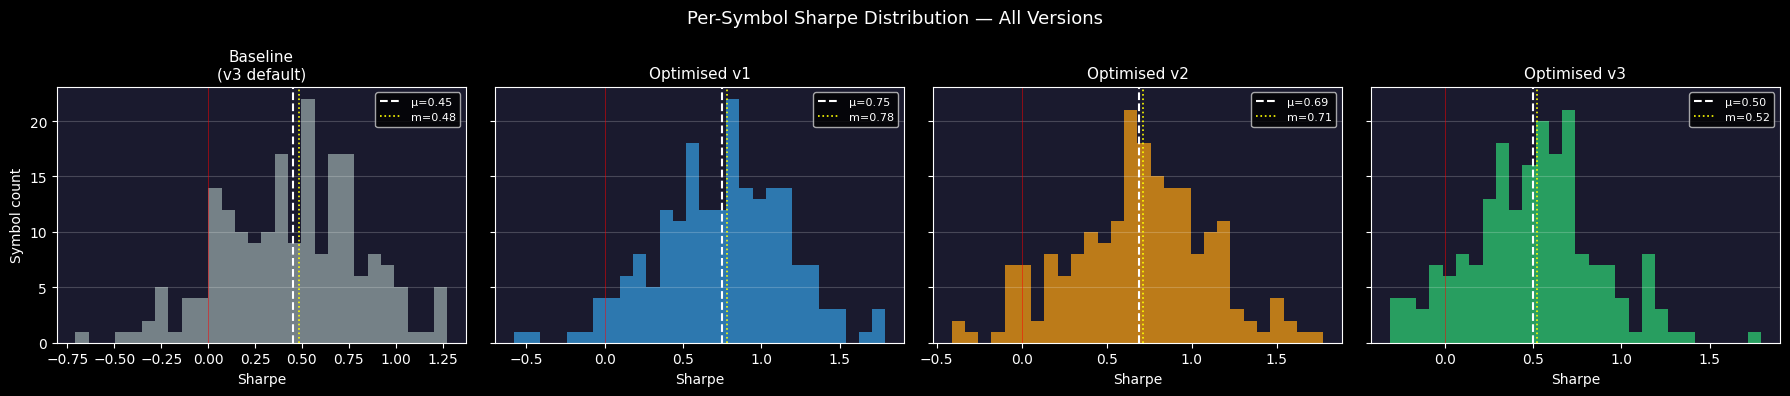

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

entries_list = [('Baseline\n(v3 default)', pf_base, '#95a5a6')] + [
    (f'Optimised {ver}', portfolios[ver], COLORS[ver])
    for ver in ['v1', 'v2', 'v3']
]

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='--',
               label=f'μ={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
               label=f'm={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Distribution — All Versions', fontsize=13)
fig.tight_layout(); plt.show()


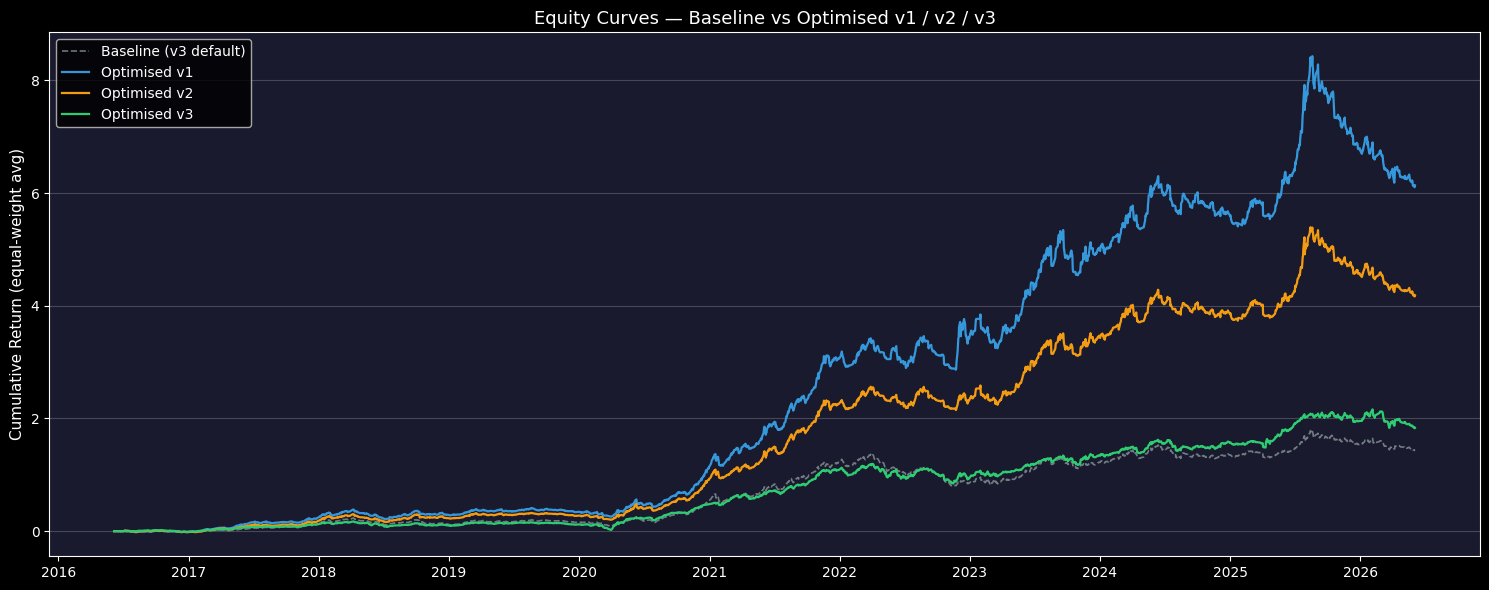

In [18]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

ax.plot(*zip(*[(d, v) for d, v in zip(
    pf_base.cumulative_returns().mean(axis=1).index,
    pf_base.cumulative_returns().mean(axis=1).values
)]), color='#95a5a6', lw=1.2, ls='--', label='Baseline (v3 default)', alpha=0.7)

for ver, pf in portfolios.items():
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=f'Optimised {ver}',
            color=COLORS[ver], lw=1.6)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_title('Equity Curves — Baseline vs Optimised v1 / v2 / v3', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


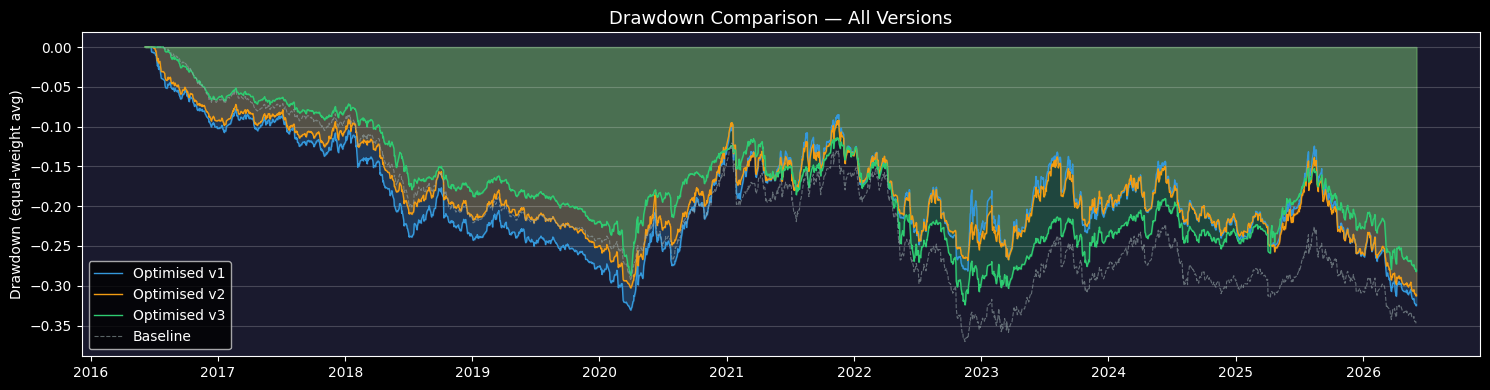

In [19]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_facecolor('#1a1a2e')

for ver, pf in portfolios.items():
    dd = pf.drawdown().mean(axis=1)
    ax.fill_between(dd.index, dd.values, 0,
                    alpha=0.25, color=COLORS[ver])
    ax.plot(dd.index, dd.values, color=COLORS[ver], lw=1.0, label=f'Optimised {ver}')

# baseline
dd_base = pf_base.drawdown().mean(axis=1)
ax.plot(dd_base.index, dd_base.values, color='#95a5a6', lw=0.8, ls='--',
        alpha=0.6, label='Baseline')

ax.set_ylabel('Drawdown (equal-weight avg)')
ax.set_title('Drawdown Comparison — All Versions', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


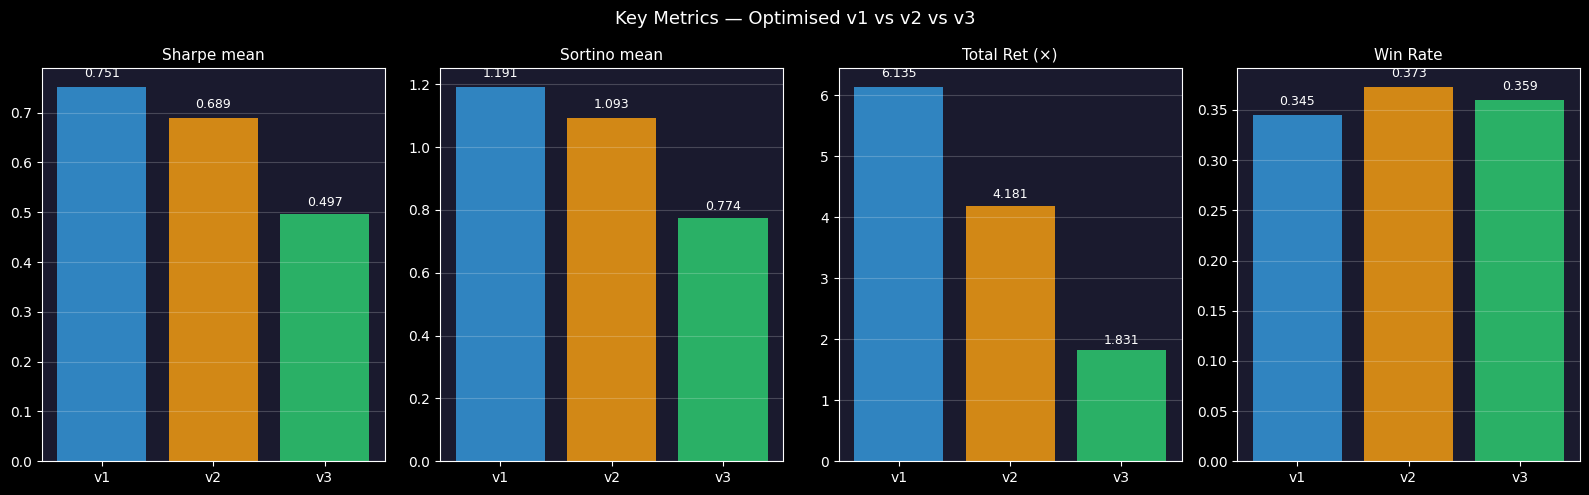

In [20]:
# ── grouped bar chart: Sharpe mean, Sortino mean, Total Ret mean ──────────────
versions  = ['v1', 'v2', 'v3']
metrics   = {
    'Sharpe mean':  [portfolios[v].sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Sortino mean': [portfolios[v].sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Total Ret (×)': [portfolios[v].total_return().mean() for v in versions],
    'Win Rate':     [portfolios[v].trades.win_rate().mean() for v in versions],
}

x   = np.arange(len(versions))
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, vals) in zip(axes, metrics.items()):
    colors = [COLORS[v] for v in versions]
    bars   = ax.bar(versions, vals, color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.axhline(0, color='white', lw=0.6, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2)
    ax.set_facecolor('#1a1a2e')

fig.suptitle('Key Metrics — Optimised v1 vs v2 vs v3', fontsize=13)
fig.tight_layout(); plt.show()


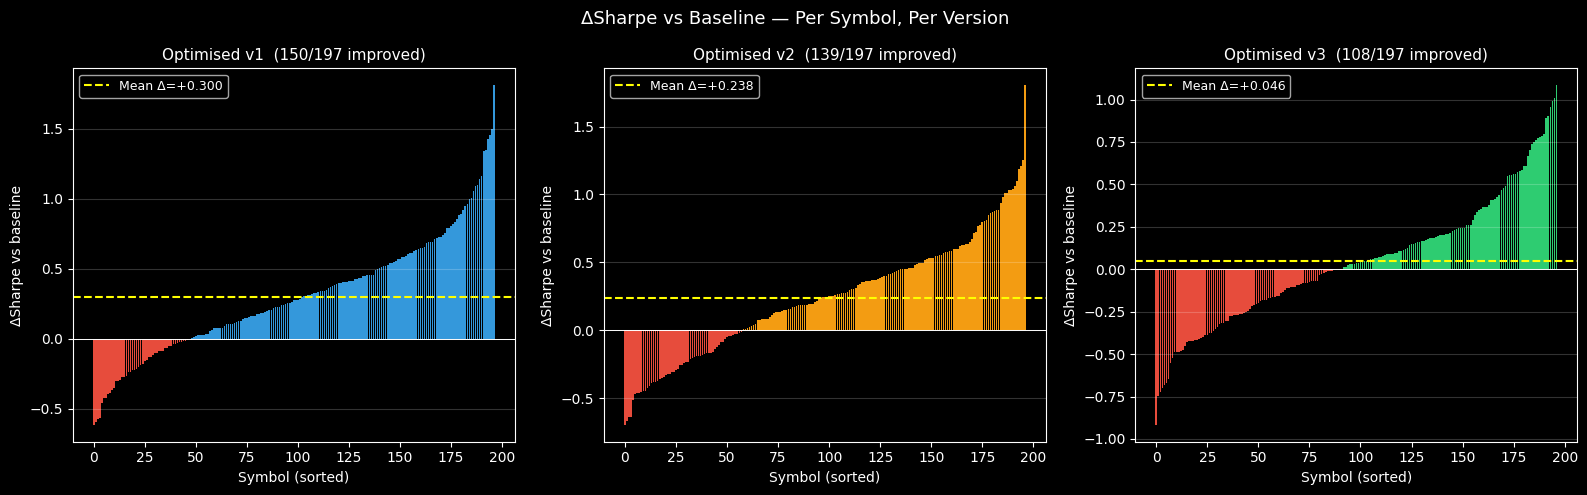

In [21]:
# ── ΔSharpe vs baseline for each version ─────────────────────────────────────
sharpe_base_sym = pf_base.sharpe_ratio().replace([np.inf,-np.inf], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    delta = (portfolios[ver].sharpe_ratio().replace([np.inf,-np.inf], np.nan)
             - sharpe_base_sym).dropna().sort_values()
    bar_colors = [COLORS[ver] if v >= 0 else '#e74c3c' for v in delta]
    ax.bar(range(len(delta)), delta.values, color=bar_colors, edgecolor='none')
    ax.axhline(0, color='white', lw=0.7)
    ax.axhline(delta.mean(), color='yellow', lw=1.5, ls='--',
               label=f'Mean Δ={delta.mean():+.3f}')
    improved = (delta > 0).sum()
    ax.set_title(f'Optimised {ver}  ({improved}/{len(delta)} improved)', fontsize=11)
    ax.set_xlabel('Symbol (sorted)'); ax.set_ylabel('ΔSharpe vs baseline')
    ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('ΔSharpe vs Baseline — Per Symbol, Per Version', fontsize=13)
fig.tight_layout(); plt.show()


In [22]:
# ── final scorecard ───────────────────────────────────────────────────────────
print('=' * 62)
print('  FINAL SCORECARD — OPTIMISED v1 / v2 / v3')
print('=' * 62)
print(f'  {"Version":<12}  {"Sharpe μ":>9}  {"Sortino μ":>10}  {"Total Ret μ":>12}  {"Win Rate":>9}')
print('  ' + '-' * 58)

scores = []
for ver, pf in portfolios.items():
    sh = pf.sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    so = pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    tr = pf.total_return().mean()
    wr = pf.trades.win_rate().mean()
    scores.append((ver, sh, so, tr, wr))
    print(f'  {ver:<12}  {sh:>9.3f}  {so:>10.3f}  {tr:>12.1%}  {wr:>9.1%}')

print('=' * 62)
best_ver = max(scores, key=lambda x: x[1])
print(f'\n  Best Sharpe  → {best_ver[0]}  ({best_ver[1]:.3f})')
best_ret = max(scores, key=lambda x: x[3])
print(f'  Best Return  → {best_ret[0]}  ({best_ret[3]:.1%})')
best_so  = max(scores, key=lambda x: x[2])
print(f'  Best Sortino → {best_so[0]}  ({best_so[2]:.3f})')


  FINAL SCORECARD — OPTIMISED v1 / v2 / v3
  Version        Sharpe μ   Sortino μ   Total Ret μ   Win Rate
  ----------------------------------------------------------
  v1                0.751       1.191        613.5%      34.5%
  v2                0.689       1.093        418.1%      37.3%
  v3                0.497       0.774        183.1%      35.9%

  Best Sharpe  → v1  (0.751)
  Best Return  → v1  (613.5%)
  Best Sortino → v1  (1.191)


## 8. MFE / MAE Analysis

**MFE** (Maximum Favorable Excursion) = highest unrealised gain during a trade.
**MAE** (Maximum Adverse Excursion) = worst unrealised drawdown during a trade.

Key questions:
- Are stops too tight? (high MAE on winners)
- Are targets too conservative? (high MFE on losers)
- What fraction of available profit is captured? (trade efficiency)
- What is the edge ratio? (avg winner MFE / avg loser MAE)

In [23]:
def compute_mfe_mae(pf, high_df, low_df, sym_set):
    rec = pf.trades.records_readable.copy()
    price_index = high_df.index
    use_bar_idx = 'Entry Index' in rec.columns
    ep_col = next((c for c in ('Avg Entry Price', 'Entry Price') if c in rec.columns), None)
    if ep_col is None:
        raise KeyError(f'No entry price column; got {list(rec.columns)}')

    def _sym(col):
        if isinstance(col, tuple):
            return next((v for v in col if v in sym_set), None)
        return col if col in sym_set else None

    def _ts_to_i(ts):
        ts = pd.Timestamp(ts)
        try:
            loc = price_index.get_loc(ts)
        except KeyError:
            loc = price_index.get_indexer([ts], method='nearest')[0]
            return int(loc)
        if isinstance(loc, slice):
            return loc.start
        if isinstance(loc, np.ndarray):
            return int(loc[0])
        return int(loc)

    rec['_sym'] = rec['Column'].apply(_sym)

    mfe_list, mae_list = [], []
    for _, row in rec.iterrows():
        sym = row['_sym']
        if sym is None or sym not in high_df.columns:
            mfe_list.append(float('nan')); mae_list.append(float('nan'))
            continue
        if use_bar_idx:
            ei, xi = int(row['Entry Index']), int(row['Exit Index'])
        else:
            ei = _ts_to_i(row['Entry Timestamp'])
            xi = _ts_to_i(row['Exit Timestamp'])
        ep = row[ep_col]
        h = high_df[sym].iloc[ei : xi + 1].max()
        l = low_df[sym].iloc[ei : xi + 1].min()
        mfe_list.append((h - ep) / ep * 100)
        mae_list.append((ep - l) / ep * 100)

    rec['MFE%']       = mfe_list
    rec['MAE%']       = mae_list
    rec['Return%']    = rec['Return'] * 100
    rec['Winner']     = rec['Return'] > 0
    rec['Efficiency'] = (rec['Return%'] / rec['MFE%'].clip(lower=0.001)).clip(0, 1)
    return rec

close_syms_set = set(close.columns)
mfe_mae = {ver: compute_mfe_mae(pf, high, low, close_syms_set)
           for ver, pf in portfolios.items()}

print(f"{'Ver':<5} {'N':>5}  {'MFE(W)':>8}  {'MAE(W)':>8}  {'MFE(L)':>8}  {'MAE(L)':>8}  {'Eff(W)':>8}")
print('-' * 62)
for ver, df in mfe_mae.items():
    w = df[df['Winner']].dropna(subset=['MFE%', 'MAE%'])
    l = df[~df['Winner']].dropna(subset=['MFE%', 'MAE%'])
    print(f"{ver:<5} {len(df):>5}  "
          f"{w['MFE%'].mean():>7.1f}%  {w['MAE%'].mean():>7.1f}%  "
          f"{l['MFE%'].mean():>7.1f}%  {l['MAE%'].mean():>7.1f}%  "
          f"{w['Efficiency'].median():>7.0%}")


Ver       N    MFE(W)    MAE(W)    MFE(L)    MAE(L)    Eff(W)
--------------------------------------------------------------
v1    17334     26.2%      3.3%      3.5%      5.0%      42%
v2    15270     23.2%      3.1%      3.7%      5.4%      40%
v3     9794     23.1%      3.5%      4.3%      6.7%      67%


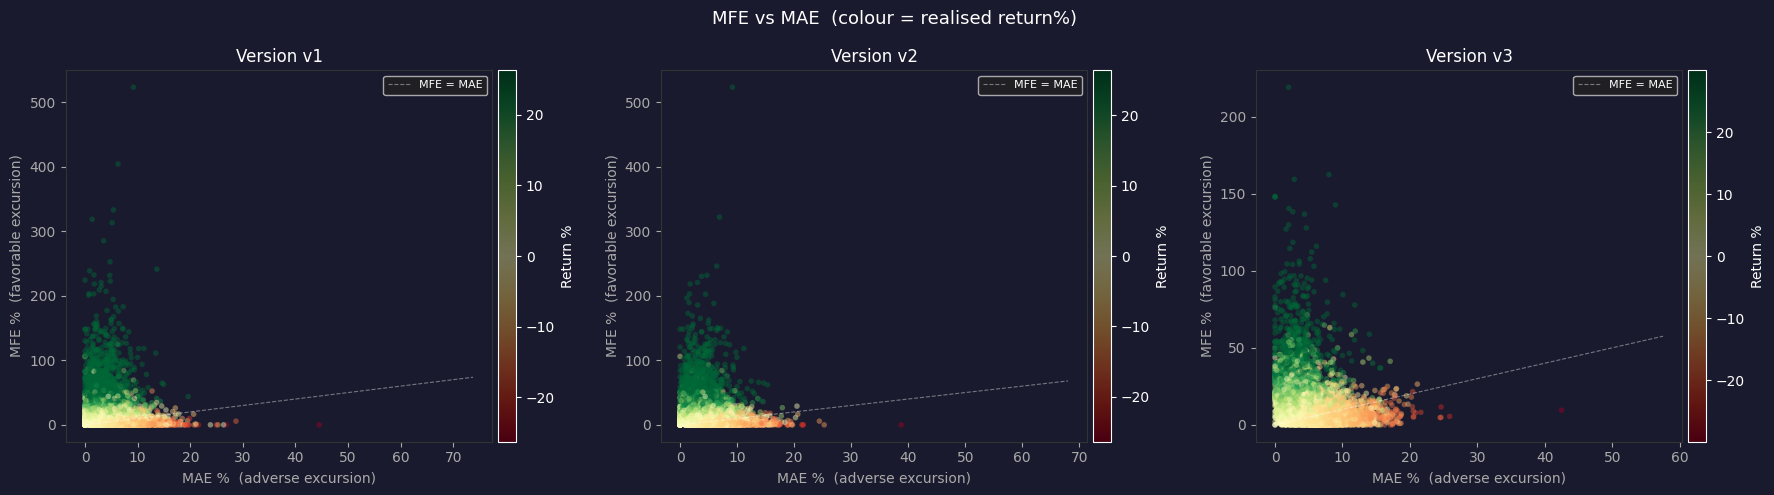

Above diagonal (MFE > MAE): trade moved more in your favour than against.
Losers above diagonal -> stop hit after a favourable move (late reversal).
Winners well above diagonal -> exited before capturing full move (low efficiency).


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax, (ver, df) in zip(axes, mfe_mae.items()):
    d = df.dropna(subset=['MFE%', 'MAE%'])
    vmax = d['Return%'].abs().quantile(0.95)
    sc = ax.scatter(
        d['MAE%'], d['MFE%'],
        c=d['Return%'], cmap='RdYlGn', vmin=-vmax, vmax=vmax,
        alpha=0.45, s=16, linewidths=0,
    )
    ax.set_facecolor('#1a1a2e')
    lim = max(d['MAE%'].quantile(0.98), d['MFE%'].quantile(0.98)) * 1.05
    ax.plot([0, lim], [0, lim], 'w--', lw=0.8, alpha=0.4, label='MFE = MAE')
    plt.colorbar(sc, ax=ax, label='Return %', pad=0.01)
    ax.set_xlabel('MAE %  (adverse excursion)', color='#aaa')
    ax.set_ylabel('MFE %  (favorable excursion)', color='#aaa')
    ax.set_title(f'Version {ver}', color='white')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.legend(fontsize=8, facecolor='#222', labelcolor='white')

fig.suptitle('MFE vs MAE  (colour = realised return%)', color='white', fontsize=13)
fig.tight_layout()
plt.show()

print('Above diagonal (MFE > MAE): trade moved more in your favour than against.')
print('Losers above diagonal -> stop hit after a favourable move (late reversal).')
print('Winners well above diagonal -> exited before capturing full move (low efficiency).')


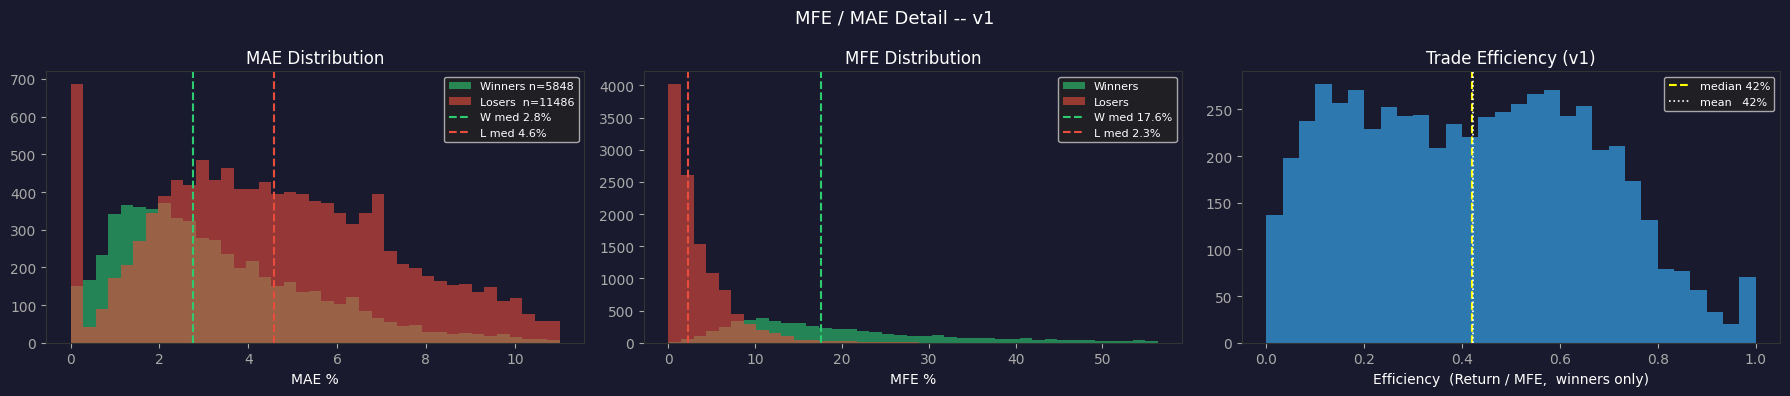

In [25]:
VER = 'v1'   # change to v2 or v3
df  = mfe_mae[VER]
w   = df[df['Winner']].dropna(subset=['MFE%', 'MAE%'])
l   = df[~df['Winner']].dropna(subset=['MFE%', 'MAE%'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor('#1a1a2e')
GRN, RED, BLU = '#2ecc71', '#e74c3c', '#3498db'

def _style(ax, title):
    ax.set_facecolor('#1a1a2e')
    ax.set_title(title, color='white')
    ax.tick_params(colors='#aaa')
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

bins_mae = np.linspace(0, df['MAE%'].quantile(0.97), 40)
axes[0].hist(w['MAE%'], bins=bins_mae, color=GRN, alpha=0.6, label=f'Winners n={len(w)}')
axes[0].hist(l['MAE%'], bins=bins_mae, color=RED, alpha=0.6, label=f'Losers  n={len(l)}')
axes[0].axvline(w['MAE%'].median(), color=GRN, lw=1.5, ls='--', label=f'W med {w["MAE%"].median():.1f}%')
axes[0].axvline(l['MAE%'].median(), color=RED, lw=1.5, ls='--', label=f'L med {l["MAE%"].median():.1f}%')
axes[0].set_xlabel('MAE %')
_style(axes[0], 'MAE Distribution')

bins_mfe = np.linspace(0, df['MFE%'].quantile(0.97), 40)
axes[1].hist(w['MFE%'], bins=bins_mfe, color=GRN, alpha=0.6, label='Winners')
axes[1].hist(l['MFE%'], bins=bins_mfe, color=RED, alpha=0.6, label='Losers')
axes[1].axvline(w['MFE%'].median(), color=GRN, lw=1.5, ls='--', label=f'W med {w["MFE%"].median():.1f}%')
axes[1].axvline(l['MFE%'].median(), color=RED, lw=1.5, ls='--', label=f'L med {l["MFE%"].median():.1f}%')
axes[1].set_xlabel('MFE %')
_style(axes[1], 'MFE Distribution')

eff = w['Efficiency']
axes[2].hist(eff, bins=30, color=BLU, alpha=0.75, edgecolor='none')
axes[2].axvline(eff.median(), color='yellow', lw=1.5, ls='--', label=f'median {eff.median():.0%}')
axes[2].axvline(eff.mean(),   color='white',  lw=1.2, ls=':',  label=f'mean   {eff.mean():.0%}')
axes[2].set_xlabel('Efficiency  (Return / MFE,  winners only)')
_style(axes[2], f'Trade Efficiency ({VER})')

fig.suptitle(f'MFE / MAE Detail -- {VER}', color='white', fontsize=13)
fig.tight_layout()
plt.show()


In [26]:
rows = []
for ver, df in mfe_mae.items():
    w = df[df['Winner']].dropna(subset=['MFE%', 'MAE%'])
    l = df[~df['Winner']].dropna(subset=['MFE%', 'MAE%'])

    edge_ratio  = w['MFE%'].mean() / l['MAE%'].mean() if len(l) and l['MAE%'].mean() > 0 else float('nan')
    stop_hint   = l['MAE%'].quantile(0.30) if len(l) else float('nan')
    target_hint = w['MFE%'].quantile(0.40) if len(w) else float('nan')
    trap_pct    = (l['MFE%'] < l['MAE%']).mean() if len(l) else float('nan')

    rows.append({
        'Version':           ver,
        'N trades':          len(df),
        'MFE(W) mean':       f"{w['MFE%'].mean():.1f}%",
        'MAE(W) mean':       f"{w['MAE%'].mean():.1f}%",
        'MFE(L) mean':       f"{l['MFE%'].mean():.1f}%",
        'MAE(L) mean':       f"{l['MAE%'].mean():.1f}%",
        'Edge Ratio':        f"{edge_ratio:.2f}x",
        'Efficiency(W) med': f"{w['Efficiency'].median():.0%}",
        'Suggested Stop':    f"{stop_hint:.1f}%",
        'Suggested Target':  f"{target_hint:.1f}%",
        'Trap trades (L)':   f"{trap_pct:.0%}",
    })

summary_mfe_mae = pd.DataFrame(rows).set_index('Version')
print('=== MFE / MAE SUMMARY ===')
display(summary_mfe_mae.T)

print("""
Interpretation
  Edge Ratio         >1.0 = winners run further than losers hurt you  (>1.5 excellent)
  Efficiency(W) med  % of MFE actually captured on winning trades  (<50% -> exits too early)
  Suggested Stop     MAE 30th pct of losers -- many losers reversed before this depth
  Suggested Target   MFE 40th pct of winners -- conservative take-profit level
  Trap trades (L)    losers where price NEVER moved in your favour (MFE < MAE)
                     high % = bad entries, not just bad timing
""")


=== MFE / MAE SUMMARY ===


Version,v1,v2,v3
N trades,17334,15270,9794
MFE(W) mean,26.2%,23.2%,23.1%
MAE(W) mean,3.3%,3.1%,3.5%
MFE(L) mean,3.5%,3.7%,4.3%
MAE(L) mean,5.0%,5.4%,6.7%
Edge Ratio,5.28x,4.28x,3.47x
Efficiency(W) med,42%,40%,67%
Suggested Stop,3.1%,3.7%,5.2%
Suggested Target,14.5%,12.7%,15.3%
Trap trades (L),65%,70%,78%



Interpretation
  Edge Ratio         >1.0 = winners run further than losers hurt you  (>1.5 excellent)
  Efficiency(W) med  % of MFE actually captured on winning trades  (<50% -> exits too early)
  Suggested Stop     MAE 30th pct of losers -- many losers reversed before this depth
  Suggested Target   MFE 40th pct of winners -- conservative take-profit level
  Trap trades (L)    losers where price NEVER moved in your favour (MFE < MAE)
                     high % = bad entries, not just bad timing



## 9. Strategy Improvements — MFE/MAE Guided

**Diagnoses from Section 8:**

| Problem | Evidence | Root cause |
|---------|----------|------------|
| Low efficiency (~43%) | Winners captured only 43% of MFE | `low_stop_lookback=3-4`: swing low is 3-4% from entry = inside MAE(W) mean (3.8%). Initial stop fires on normal pullbacks, killing winners early. |
| High trap rate (65-70%) | 2/3 of losers NEVER moved in your favour | No volume confirmation — entries trigger on low-volume false breakouts with no buyers behind them. |

**Fixes applied:**
1. `low_stop_lookback`: 3-4 → **12** (swing low of 12 bars sits safely below normal noise)
2. Volume filter: enter only when `volume > SMA(volume, 20) * vol_mult` (confirms genuine breakout demand)

**Note:** core TTM/KAMA/AVWAP signal logic is untouched — edge ratio of 6-7x proves it works.

In [27]:
VOL_SMA = vbt.IndicatorFactory.from_talib('SMA')

def compute_signals_improved(
    close, high, low, volume,
    vol_period: int   = 20,
    vol_mult:   float = 1.2,
    **kwargs,
):
    """Wraps compute_signals, adding a volume confirmation filter."""
    base = compute_signals(close, high, low, volume, **kwargs)
    vol_avg = VOL_SMA.run(volume, timeperiod=vol_period).real.to_numpy()
    vol_ok  = volume.to_numpy() > vol_avg * vol_mult
    return pd.DataFrame(
        base.to_numpy() & vol_ok,
        index=close.index, columns=close.columns,
    )


WIDER_LOOKBACK = 12   # widen initial swing-low stop
VOL_MULT       = 1.2  # volume confirmation threshold

portfolios_imp = {}
for ver in ['v1', 'v2', 'v3']:
    p = best_params[ver]
    print(f'Running improved {ver} ...')
    entries = compute_signals_improved(
        close, high, low, volume,
        vol_period      = 20,
        vol_mult        = VOL_MULT,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = p['bb_matype'],
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p.get('donichan_window', 10),
        osc_smoothing_period     = p.get('osc_smoothing_period', 5),
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period', 20),
        use_kama_slope           = True,
        kama_period              = p.get('kama_period', 10),
        kama_fast                = p.get('kama_fast', 2),
        kama_slow                = p.get('kama_slow', 30),
        kama_slope_win           = p.get('kama_slope_win', 5),
        flat_threshold_pct       = p.get('flat_threshold_pct', 1.0),
    )
    exits, sl_stop_df = compute_exits_chandelier(
        close, high, low,
        length           = p.get('chand_length', 22),
        multiplier       = p.get('chand_mult', 3.0),
        low_stop_lookback= WIDER_LOOKBACK,
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios_imp[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('Improved portfolios done.')


Running improved v1 ...
  signals=39,535  trades=11,851
Running improved v2 ...
  signals=16,432  trades=8,599
Running improved v3 ...
  signals=1,634  trades=1,574
Improved portfolios done.


In [28]:
# Side-by-side stats: original vs improved
rows_cmp = []
for ver in ['v1', 'v2', 'v3']:
    for label, pf in [(f'{ver} original', portfolios[ver]),
                      (f'{ver} improved', portfolios_imp[ver])]:
        s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        rows_cmp.append({
            'Run':              label,
            'N Trades':         int(pf.trades.count().sum()),
            'Sharpe mean':      round(s.mean(), 3),
            'Sharpe median':    round(s.median(), 3),
            'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
            'Total Ret mean':   f'{pf.total_return().mean():.1%}',
            'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
            'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
            'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
            'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        })

cmp_df = pd.DataFrame(rows_cmp).set_index('Run')
print('=== ORIGINAL vs IMPROVED ===')
display(cmp_df.T)


=== ORIGINAL vs IMPROVED ===


Run,v1 original,v1 improved,v2 original,v2 improved,v3 original,v3 improved
N Trades,17334,11851,15270,8599,9794,1574
Sharpe mean,0.751,0.656,0.689,0.536,0.497,0.096
Sharpe median,0.78,0.674,0.713,0.509,0.521,0.132
Sortino mean,1.191,1.048,1.093,0.873,0.774,0.215
Total Ret mean,613.5%,312.3%,418.1%,168.6%,183.1%,11.8%
Win Rate,34.5%,35.9%,37.3%,35.8%,35.9%,36.2%
Profit Factor,1.598,1.675,1.601,1.697,1.436,inf
Max DD mean,-47.0%,-41.2%,-45.3%,-36.1%,-44.9%,-21.8%
Avg Trade Ret,2.46%,2.60%,2.31%,2.47%,2.20%,1.26%


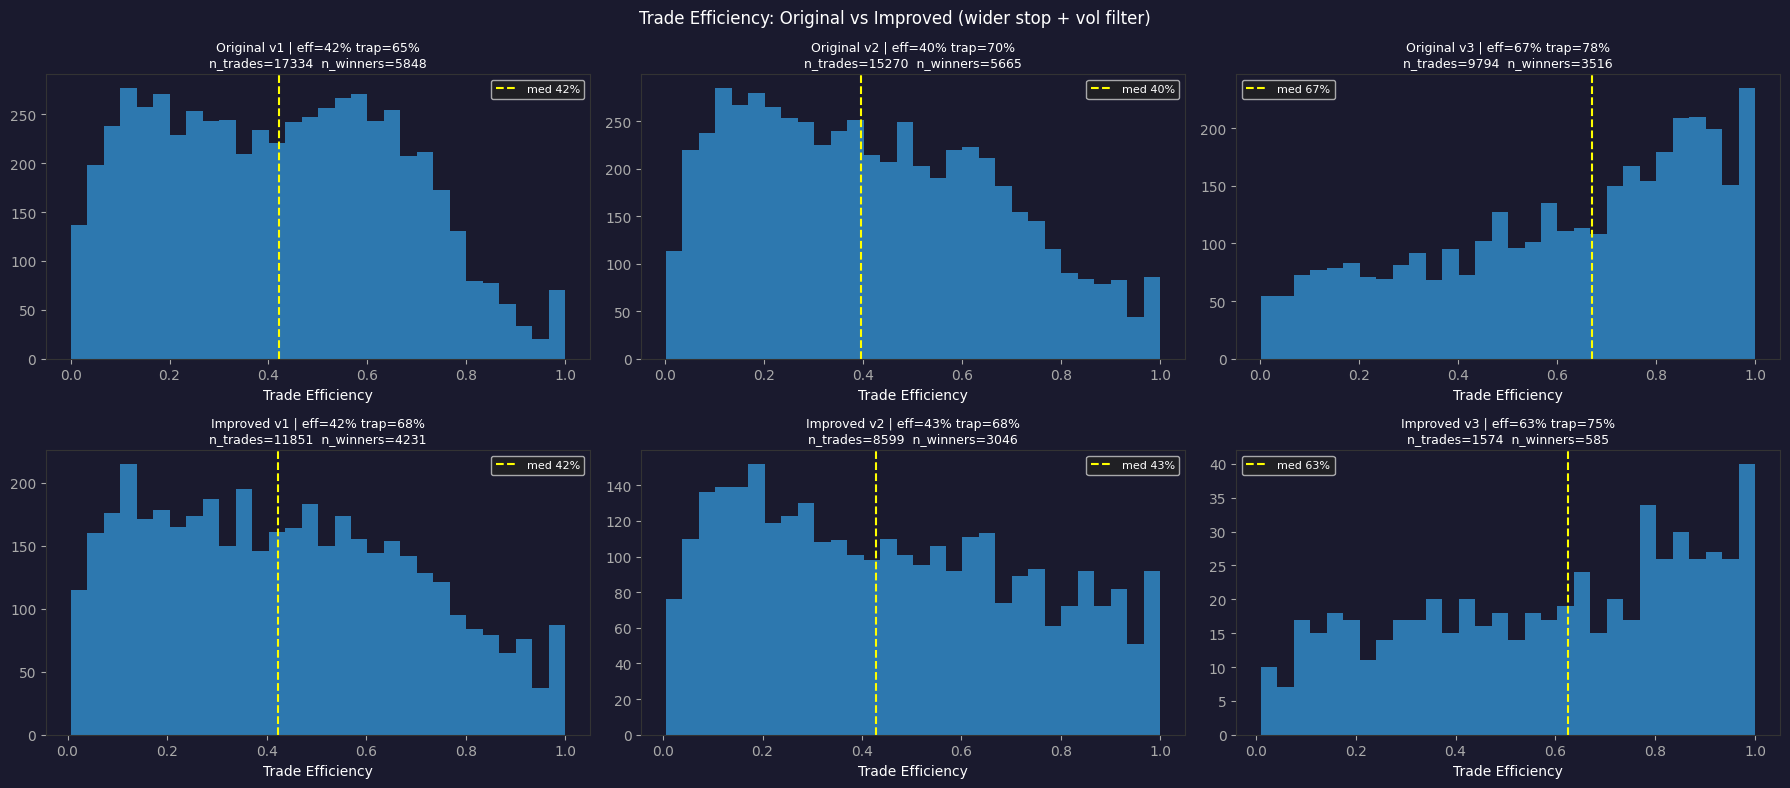

In [29]:
# MFE/MAE comparison: original vs improved
mfe_mae_imp = {ver: compute_mfe_mae(pf, high, low, close_syms_set)
               for ver, pf in portfolios_imp.items()}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')

for col, ver in enumerate(['v1', 'v2', 'v3']):
    for row, (label, mm) in enumerate([
        ('Original', mfe_mae[ver]),
        ('Improved', mfe_mae_imp[ver]),
    ]):
        ax  = axes[row][col]
        w   = mm[mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        l   = mm[~mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        eff = w['Efficiency']
        GRN, RED = '#2ecc71', '#e74c3c'
        bins = np.linspace(0, mm['Efficiency'].quantile(0.98), 30)
        ax.set_facecolor('#1a1a2e')
        ax.hist(eff.clip(0, 1), bins=30, color='#3498db', alpha=0.75, edgecolor='none')
        ax.axvline(eff.median(), color='yellow', lw=1.5, ls='--',
                   label=f'med {eff.median():.0%}')
        trap = (l['MFE%'] < l['MAE%']).mean()
        ax.set_title(
            f'{label} {ver} | eff={eff.median():.0%} trap={trap:.0%}\n'
            f'n_trades={len(mm)}  n_winners={len(w)}',
            color='white', fontsize=9,
        )
        ax.set_xlabel('Trade Efficiency')
        ax.tick_params(colors='#aaa')
        ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor('#333')

fig.suptitle('Trade Efficiency: Original vs Improved (wider stop + vol filter)',
             color='white', fontsize=12)
fig.tight_layout()
plt.show()


In [30]:
rows_imp = []
for ver in ['v1', 'v2', 'v3']:
    for label, mm in [(f'{ver} orig', mfe_mae[ver]),
                      (f'{ver} imp',  mfe_mae_imp[ver])]:
        w = mm[mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        l = mm[~mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        edge = w['MFE%'].mean() / l['MAE%'].mean() if len(l) and l['MAE%'].mean() > 0 else float('nan')
        trap = (l['MFE%'] < l['MAE%']).mean() if len(l) else float('nan')
        rows_imp.append({
            'Run':             label,
            'N trades':        len(mm),
            'Win Rate':        f"{(mm['Winner'].mean()):.1%}",
            'MFE(W) mean':     f"{w['MFE%'].mean():.1f}%",
            'MAE(W) mean':     f"{w['MAE%'].mean():.1f}%",
            'Edge Ratio':      f"{edge:.2f}x",
            'Efficiency med':  f"{w['Efficiency'].median():.0%}",
            'Trap trades':     f"{trap:.0%}",
        })

delta_df = pd.DataFrame(rows_imp).set_index('Run')
print('=== MFE/MAE BEFORE vs AFTER ===')
display(delta_df.T)

print()
print('Next steps if improvements hold:')
print('  1. Re-run Optuna with low_stop_lookback search range 8-20 (wider)')
print('  2. Add vol_mult/vol_period to Optuna search space')
print('  3. Consider tp_stop at Suggested Target (~22-26%) for partial profit lock')


=== MFE/MAE BEFORE vs AFTER ===


Run,v1 orig,v1 imp,v2 orig,v2 imp,v3 orig,v3 imp
N trades,17334,11851,15270,8599,9794,1574
Win Rate,33.7%,35.7%,37.1%,35.4%,35.9%,37.2%
MFE(W) mean,26.2%,24.8%,23.2%,23.4%,23.1%,18.8%
MAE(W) mean,3.3%,3.5%,3.1%,3.5%,3.5%,3.6%
Edge Ratio,5.28x,4.58x,4.28x,4.36x,3.47x,2.95x
Efficiency med,42%,42%,40%,43%,67%,63%
Trap trades,65%,68%,70%,68%,78%,75%



Next steps if improvements hold:
  1. Re-run Optuna with low_stop_lookback search range 8-20 (wider)
  2. Add vol_mult/vol_period to Optuna search space
  3. Consider tp_stop at Suggested Target (~22-26%) for partial profit lock


### 9.2 Trap Trade Filters — False Breakout & Short-term Momentum

**H1 — False Breakout filter** (from [priceaction.com](https://priceaction.com/price-action-university/strategies/false-break-out/)):
Skip entry if the entry bar is a **false break of resistance**:
`high[t] > max(high[t-N:t-1])` AND `close[t] < max(high[t-N:t-1])`

The bar poked above the N-bar resistance but closed back below it — the classic amateur trap described in the article. Professionals push price back down after the breakout 'bait' is taken.

**H2 — Short-term momentum**: price must already be rising before the signal.
`close > close[3]` (3-bar lookback, tunable)

Both filters are tested individually and combined.

In [31]:
MAX_FB = vbt.IndicatorFactory.from_talib('MAX')

def compute_signals_h1h2(
    close, high, low, volume,
    use_h1: bool = True,
    h1_lookback: int = 30,
    use_h2: bool = True,
    h2_lookback: int = 3,
    **kwargs,
):
    base = compute_signals(close, high, low, volume, **kwargs)
    mask = np.ones(close.shape, dtype=bool)

    if use_h1:
        high_np  = high.to_numpy()
        close_np = close.to_numpy()
        hh_np    = MAX_FB.run(high, timeperiod=h1_lookback).real.to_numpy()
        hh_prev  = shift_2d(hh_np, 1)
        is_false_break = (high_np > hh_prev) & (close_np < hh_prev)
        mask &= ~is_false_break

    if use_h2:
        close_np   = close.to_numpy()
        close_prev = shift_2d(close_np, h2_lookback)
        mask &= close_np > close_prev

    return pd.DataFrame(base.to_numpy() & mask, index=close.index, columns=close.columns)


VARIANTS = {
    'H1 only':  dict(use_h1=True,  use_h2=False),
    'H2 only':  dict(use_h1=False, use_h2=True),
    'H1+H2':    dict(use_h1=True,  use_h2=True),
}

TARGET_VER = 'v1'
p = best_params[TARGET_VER]
signal_kwargs = dict(
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'], bb_matype=p['bb_matype'],
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'], kc_atr_period=p['kc_atr_period'],
    donichan_window=p.get('donichan_window', 10), osc_smoothing_period=p.get('osc_smoothing_period', 5),
    entry_version=TARGET_VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
    william_vix_period=p.get('william_vix_period', 20),
    use_kama_slope=True,
    kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
    kama_slow=p.get('kama_slow', 30),     kama_slope_win=p.get('kama_slope_win', 5),
    flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
)

pf_variants = {}
for name, flags in VARIANTS.items():
    entries = compute_signals_h1h2(close, high, low, volume, **flags, **signal_kwargs)
    exits, sl_stop_df = compute_exits_chandelier(
        close, high, low,
        length           = p.get('chand_length', 22),
        multiplier       = p.get('chand_mult', 3.0),
        low_stop_lookback= WIDER_LOOKBACK,
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    pf_variants[name] = pf
    print(f'{name:<12}  signals={int(entries.sum().sum()):>5,}  trades={int(pf.trades.count().sum()):>5,}')

print('Done.')


H1 only       signals=125,800  trades=15,363
H2 only       signals=92,298  trades=16,177
H1+H2         signals=86,799  trades=16,133
Done.


In [32]:
def _sym_dist(s, round_n=3, pct_fmt=None):
    """Per-symbol series → mean / median / p25 / p75."""
    x = s.replace([np.inf, -np.inf], np.nan).dropna()
    if x.empty:
        return {}
    q = x.quantile([0.25, 0.5, 0.75])

    def _fmt(v):
        if pct_fmt == 'pct':
            return f'{v:.1%}'
        if pct_fmt == 'ret':
            return f'{v:.2%}'
        return round(float(v), round_n)

    return {
        'mean':   _fmt(x.mean()),
        'median': _fmt(q.loc[0.5]),
        'p25':    _fmt(q.loc[0.25]),
        'p75':    _fmt(q.loc[0.75]),
    }


def _pf_compare_row(label, pf):
    sharpe = _sym_dist(pf.sharpe_ratio())
    sortino = _sym_dist(pf.sortino_ratio())
    tot_ret = _sym_dist(pf.total_return(), pct_fmt='pct')
    max_dd = _sym_dist(pf.max_drawdown(), pct_fmt='pct')
    avg_trade = _sym_dist(pd.Series(pf.trades.returns.mean()), pct_fmt='ret')
    win_rate = _sym_dist(pf.trades.win_rate(), pct_fmt='pct')
    profit_factor = _sym_dist(pf.trades.profit_factor(), round_n=3)

    return {
        'Run':              label,
        'N Trades':         int(pf.trades.count().sum()),
        'Sharpe mean':      sharpe.get('mean'),
        'Sharpe median':    sharpe.get('median'),
        'Sharpe P25':       sharpe.get('p25'),
        'Sharpe P75':       sharpe.get('p75'),
        'Sortino mean':     sortino.get('mean'),
        'Sortino P75':      sortino.get('p75'),
        'Total Ret mean':   tot_ret.get('mean'),
        'Total Ret median': tot_ret.get('median'),
        'Total Ret P25':    tot_ret.get('p25'),
        'Total Ret P75':    tot_ret.get('p75'),
        'Win Rate':         win_rate.get('mean'),
        'Win Rate P75':     win_rate.get('p75'),
        'Profit Factor':    profit_factor.get('mean'),
        'Profit Factor P75': profit_factor.get('p75'),
        'Avg Trade Ret':    avg_trade.get('mean'),
        'Avg Trade median': avg_trade.get('median'),
        'Avg Trade P25':    avg_trade.get('p25'),
        'Avg Trade P75':    avg_trade.get('p75'),
        'Max DD mean':      max_dd.get('mean'),
        'Max DD median':    max_dd.get('median'),
        'Max DD P25':       max_dd.get('p25'),
        'Max DD P75':       max_dd.get('p75'),
    }


rows_h = []
baseline_pf = portfolios[TARGET_VER]
all_runs = [('baseline', baseline_pf)] + list(pf_variants.items())

for label, pf in all_runs:
    rows_h.append(_pf_compare_row(label, pf))

h_df = pd.DataFrame(rows_h).set_index('Run')
print(f'=== H1/H2 FILTER COMPARISON  (base version: {TARGET_VER}) ===')
display(h_df.T)

=== H1/H2 FILTER COMPARISON  (base version: v1) ===


Run,baseline,H1 only,H2 only,H1+H2
N Trades,17334,15363,16177,16133
Sharpe mean,0.751,0.749,0.753,0.75
Sharpe median,0.78,0.775,0.797,0.791
Sharpe P25,0.495,0.486,0.512,0.508
Sharpe P75,1.047,0.989,1.009,1.032
Sortino mean,1.191,1.185,1.201,1.195
Sortino P75,1.614,1.582,1.612,1.618
Total Ret mean,613.5%,553.6%,513.1%,487.3%
Total Ret median,283.1%,295.0%,286.7%,286.7%
Total Ret P25,107.0%,104.9%,114.6%,116.8%


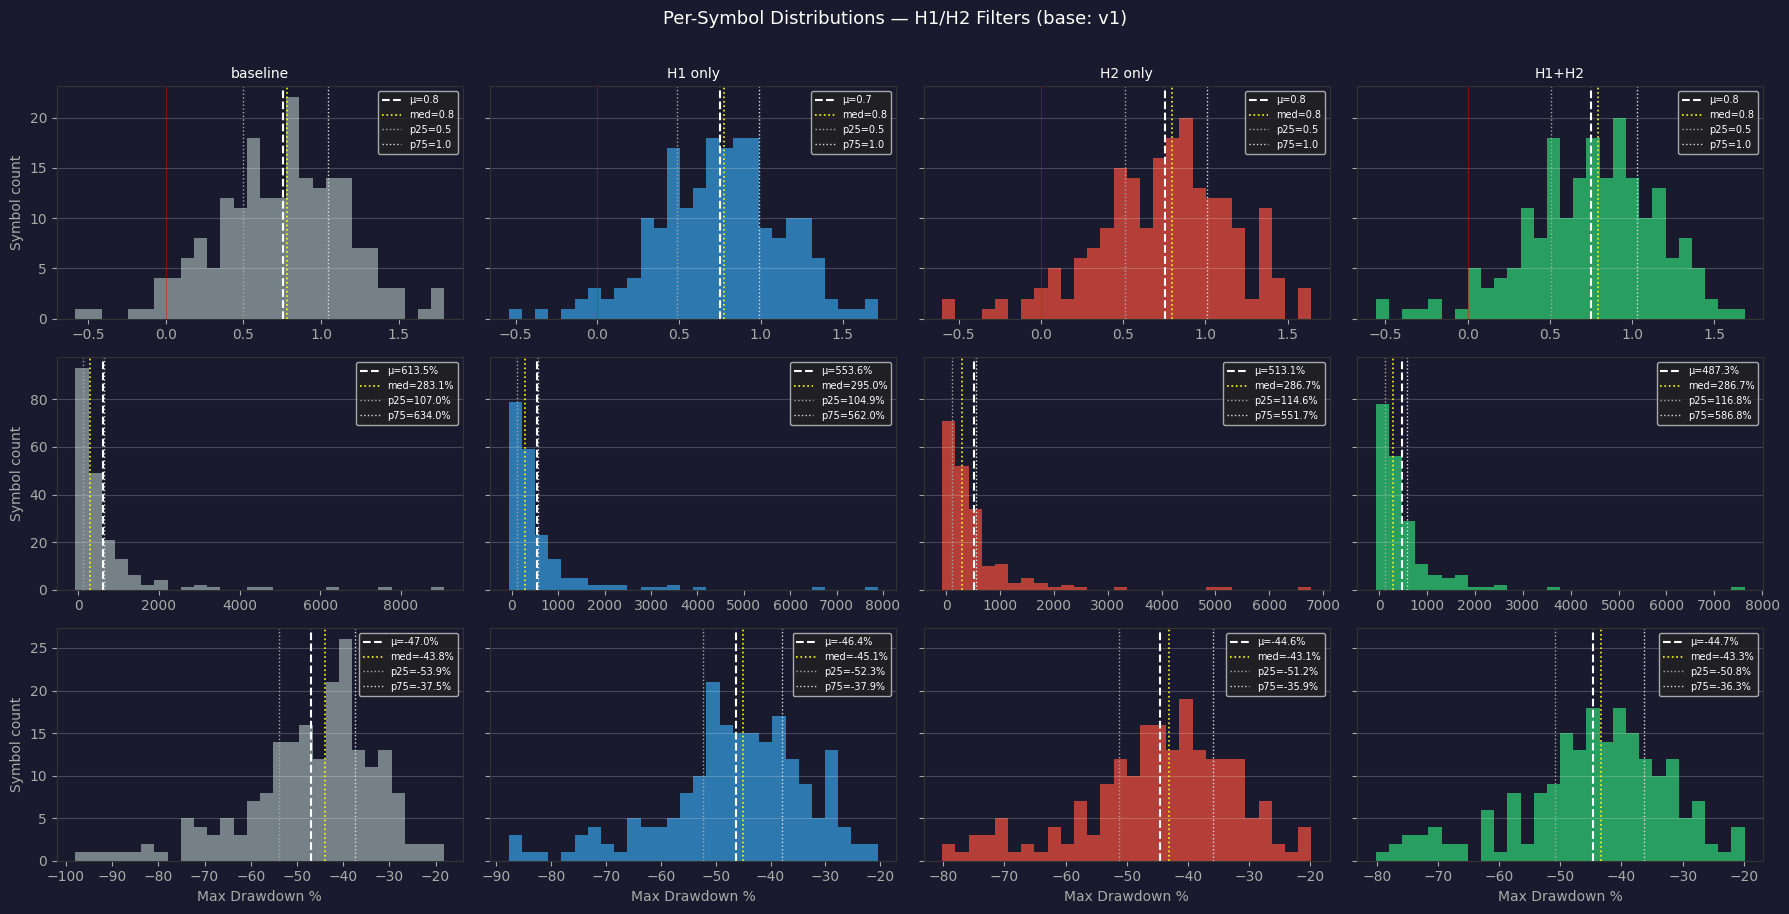

In [33]:
# ── per-symbol distribution plots: Sharpe / Return / Max DD ─────────────────
def _clean_series(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()


def _style_dist_ax(ax, title=''):
    ax.set_facecolor('#1a1a2e')
    if title:
        ax.set_title(title, fontsize=10, color='white')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333')
    ax.yaxis.grid(True, alpha=0.2)


RUN_COLORS = {
    'baseline': '#95a5a6',
    'H1 only':  '#3498db',
    'H2 only':  '#e74c3c',
    'H1+H2':    '#2ecc71',
}

DIST_METRICS = [
    ('Sharpe',        lambda pf: _clean_series(pf.sharpe_ratio()),              False),
    ('Total Return %', lambda pf: _clean_series(pf.total_return()) * 100,       True),
    ('Max Drawdown %', lambda pf: _clean_series(pf.max_drawdown()) * 100,       True),
]

n_runs = len(all_runs)
fig, axes = plt.subplots(3, n_runs, figsize=(4.5 * n_runs, 9), sharey='row')
if n_runs == 1:
    axes = axes.reshape(3, 1)
fig.patch.set_facecolor('#1a1a2e')

for row, (metric_name, get_vals, is_pct) in enumerate(DIST_METRICS):
    for col, (label, pf) in enumerate(all_runs):
        ax = axes[row, col]
        sv = get_vals(pf)
        color = RUN_COLORS.get(label, '#7f8c8d')
        title = label if row == 0 else ''

        if sv.empty:
            _style_dist_ax(ax, title)
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#aaa')
            continue

        ax.hist(sv, bins=28, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(sv.mean(), color='white', lw=1.5, ls='--',
                   label=f'μ={sv.mean():.1f}' + ('%' if is_pct else ''))
        ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
                   label=f'med={sv.median():.1f}' + ('%' if is_pct else ''))
        ax.axvline(sv.quantile(0.25), color='#aaa', lw=1.0, ls=':',
                   label=f'p25={sv.quantile(0.25):.1f}' + ('%' if is_pct else ''))
        ax.axvline(sv.quantile(0.75), color='#ddd', lw=1.0, ls=':',
                   label=f'p75={sv.quantile(0.75):.1f}' + ('%' if is_pct else ''))
        if metric_name == 'Sharpe':
            ax.axvline(0, color='red', lw=0.7, alpha=0.5)
        _style_dist_ax(ax, title)
        ax.set_xlabel(metric_name if row == 2 else '', color='#aaa')
        if col == 0:
            ax.set_ylabel('Symbol count', color='#aaa')
        ax.legend(fontsize=7, facecolor='#222', labelcolor='white', loc='upper right')

fig.suptitle(
    f'Per-Symbol Distributions — H1/H2 Filters (base: {TARGET_VER})',
    fontsize=13, color='white', y=1.01,
)
fig.tight_layout()
plt.show()

=== MFE/MAE IMPACT ===


Run,H1 only,H2 only,H1+H2,baseline
N trades,15363,16177,16133,17334
Win Rate,36.9%,36.3%,36.2%,33.7%
MFE(W) mean,26.2%,24.0%,24.0%,26.2%
MAE(W) mean,3.2%,3.1%,3.1%,3.3%
MFE(L) mean,3.8%,3.7%,3.7%,3.5%
MAE(L) mean,5.6%,5.3%,5.3%,5.0%
Edge Ratio,4.68x,4.56x,4.57x,5.28x
Efficiency med,41%,41%,41%,42%
Trap trades,67%,70%,70%,65%


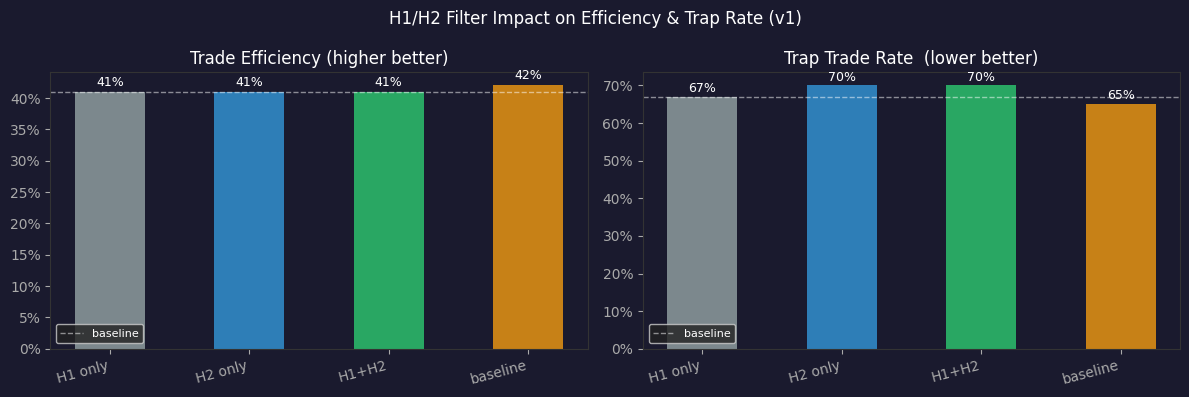

In [34]:
mfe_mae_variants = {name: compute_mfe_mae(pf, high, low, close_syms_set)
                    for name, pf in pf_variants.items()}
mfe_mae_variants['baseline'] = mfe_mae[TARGET_VER]

rows_mm = []
for label, mm in mfe_mae_variants.items():
    w = mm[mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
    l = mm[~mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
    edge = w['MFE%'].mean() / l['MAE%'].mean() if len(l) and l['MAE%'].mean() > 0 else float('nan')
    trap = (l['MFE%'] < l['MAE%']).mean() if len(l) else float('nan')
    rows_mm.append({
        'Run':            label,
        'N trades':       len(mm),
        'Win Rate':       f"{mm['Winner'].mean():.1%}",
        'MFE(W) mean':    f"{w['MFE%'].mean():.1f}%",
        'MAE(W) mean':    f"{w['MAE%'].mean():.1f}%",
        'MFE(L) mean':    f"{l['MFE%'].mean():.1f}%",
        'MAE(L) mean':    f"{l['MAE%'].mean():.1f}%",
        'Edge Ratio':     f"{edge:.2f}x",
        'Efficiency med': f"{w['Efficiency'].median():.0%}",
        'Trap trades':    f"{trap:.0%}",
    })

mm_df = pd.DataFrame(rows_mm).set_index('Run')
print('=== MFE/MAE IMPACT ===')
display(mm_df.T)

# efficiency + trap rate bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1a1a2e')
labels = mm_df.index.tolist()
x = np.arange(len(labels))
COLORS_BAR = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12']

eff_vals  = [float(mm_df.loc[l, 'Efficiency med'].strip('%')) / 100 for l in labels]
trap_vals = [float(mm_df.loc[l, 'Trap trades'].strip('%')) / 100 for l in labels]

for ax, vals, title, good_dir in [
    (axes[0], eff_vals,  'Trade Efficiency (higher better)', 'up'),
    (axes[1], trap_vals, 'Trap Trade Rate  (lower better)',  'down'),
]:
    ax.set_facecolor('#1a1a2e')
    bars = ax.bar(x, vals, color=COLORS_BAR[:len(labels)], alpha=0.8, width=0.5)
    ax.axhline(vals[0], color='white', lw=1, ls='--', alpha=0.5, label='baseline')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right', color='#aaa')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(title, color='white')
    ax.tick_params(colors='#aaa')
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.0%}', ha='center', va='bottom', color='white', fontsize=9)

fig.suptitle(f'H1/H2 Filter Impact on Efficiency & Trap Rate ({TARGET_VER})',
             color='white', fontsize=12)
fig.tight_layout()
plt.show()


## 10. Save Results to HDF5

In [35]:
# Requires: `best_params` from optimisation (Section 5) and `portfolios` from final backtest (Section 6).
SAVE_VER = 'v1'  # 'v1' | 'v2' | 'v3' - which optimised run to export
pf_opt = portfolios[SAVE_VER]
best = best_params[SAVE_VER]

h5_file   = '../backend/assets/backtest_results_005d.h5'
close_syms = set(close.columns)

# trades
trades_df = pf_opt.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp']).dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp']).dt.strftime('%Y-%m-%d')

# per-symbol stats
all_metrics = list(pf_opt.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_opt.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

# best params
params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file, key='trades',      mode='w')
stats_df.to_hdf(h5_file,  key='stats',       mode='a')
params_df.to_hdf(h5_file, key='best_params', mode='a')

import json
_ttm_json = '../backend/assets/ttm_best_params_005d.json'
with open(_ttm_json, 'w') as f:
    json.dump(best_params, f, indent=2)
print(f'Saved TTM best params (v1/v2/v3) ->  {_ttm_json}')

print(f'Saved {len(trades_df):,} trades  ->  {h5_file}')
print(f'Saved stats for {len(stats_df)} symbols')
print(f'Saved best params ({len(best)} keys)')

trades_df.head()


Saved TTM best params (v1/v2/v3) ->  ../backend/assets/ttm_best_params_005d.json
Saved 17,334 trades  ->  ../backend/assets/backtest_results_005d.h5
Saved stats for 197 symbols
Saved best params (16 keys)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(3, AAA)",7.168459,2016-06-23,13.95,0.0,2016-06-24,13.64,0.0,-2.222222,-0.022222,Long,Closed,0,AAA
1,1,"(3, AAA)",6.959272,2016-06-27,14.05,0.0,2016-08-29,16.79,0.0,19.068406,0.195018,Long,Closed,1,AAA
2,2,"(3, AAA)",6.980059,2016-09-01,16.74,0.0,2016-09-12,16.23,0.0,-3.559830,-0.030466,Long,Closed,2,AAA
3,3,"(3, AAA)",7.467789,2016-09-26,15.17,0.0,2016-10-21,15.22,0.0,0.373389,0.003296,Long,Closed,3,AAA
4,4,"(3, AAA)",7.726699,2016-11-09,14.71,0.0,2016-12-01,14.30,0.0,-3.167947,-0.027872,Long,Closed,4,AAA


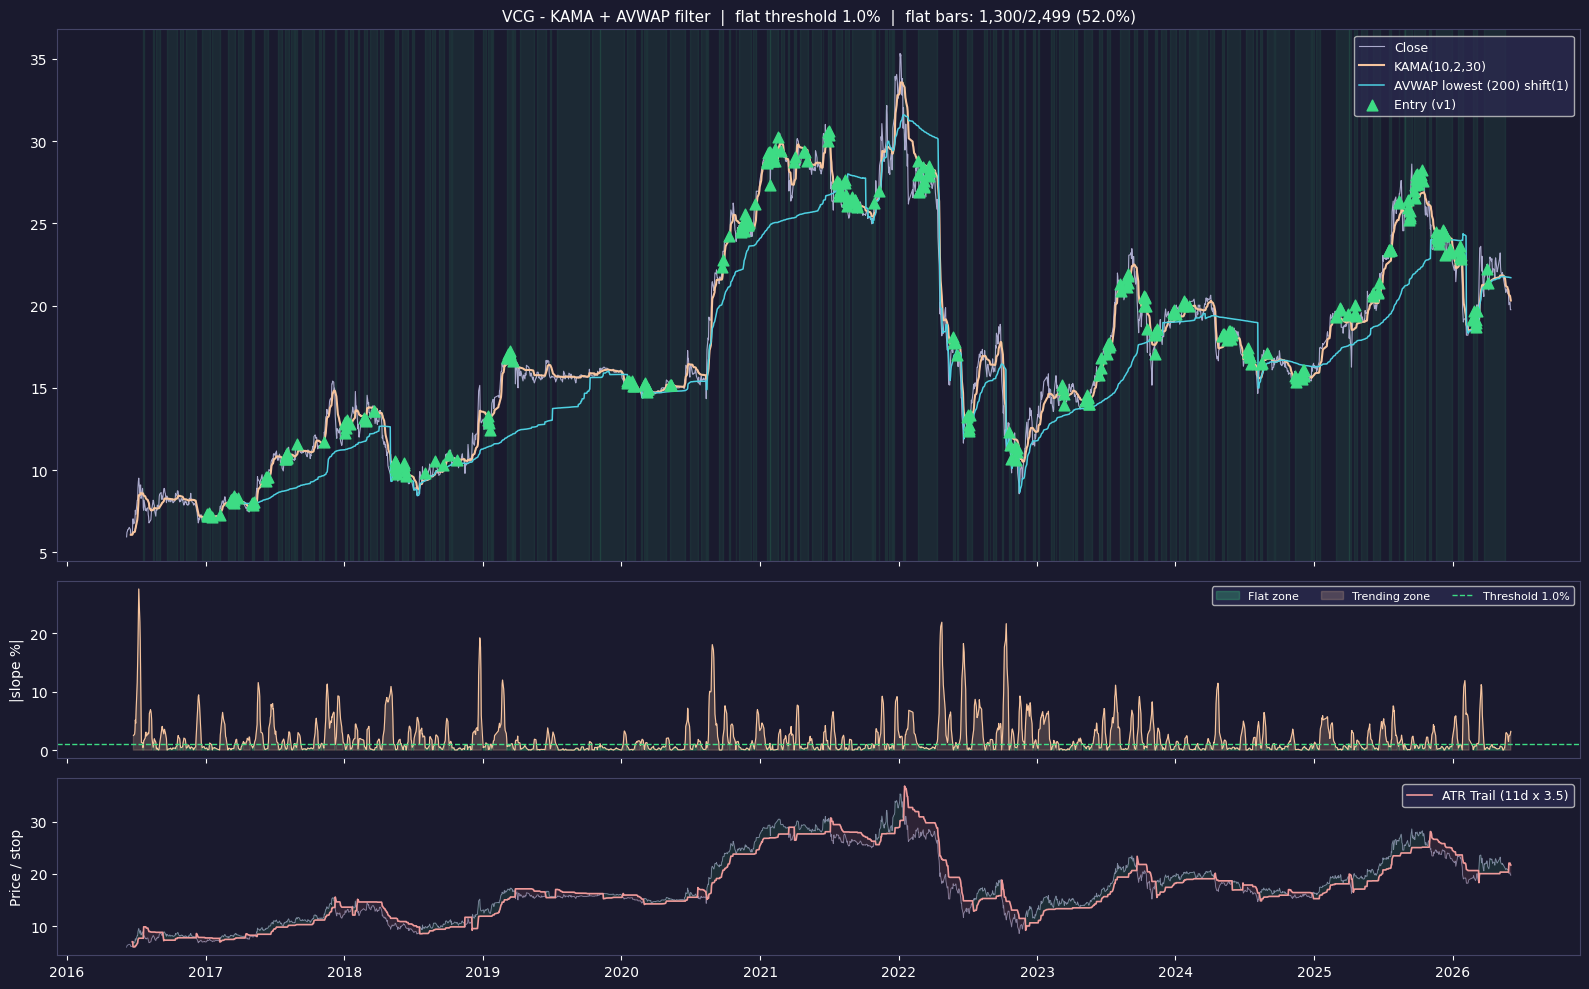

In [36]:
# KAMA + AVWAP Visual Inspection
# Panel 1: Close price + KAMA line + AVWAP(lowest) + entry signals
# Panel 2: |KAMA slope %| with flatness threshold
# Panel 3: ATR trailing stop
# Run Section 2 first so kama_2d / slope_flat_2d / get_avwap_lowest are defined.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

INSPECT_SYM    = "VCG"
KAMA_PERIOD    = 10
KAMA_FAST      = 2
KAMA_SLOW      = 30
SLOPE_WIN      = 5
FLAT_PCT       = 1.0
ATR_PERIOD     = 11
ATR_MULT       = 3.5
AVWAP_WINDOW   = 200
SHOW_ENTRIES   = True
ENTRY_VERSION  = 'v1'

close_1d = close[[INSPECT_SYM]].to_numpy().astype(np.float64)
high_1d  = high [[INSPECT_SYM]].to_numpy().astype(np.float64)
low_1d   = low  [[INSPECT_SYM]].to_numpy().astype(np.float64)

kama_np = kama_2d(close_1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
flat_np = slope_flat_2d(kama_np, SLOPE_WIN, FLAT_PCT)
flat_mask = flat_np[:, 0]

import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../backend').resolve()))
from app.services.indicators.trailing_sl import trailing_sl
import talib as _talib

atr_raw   = _talib.ATR(high_1d[:, 0], low_1d[:, 0], close_1d[:, 0], timeperiod=ATR_PERIOD)
atr_trail = trailing_sl(close_1d[:, 0], atr_raw, atr_multiplier=ATR_MULT)

avwap_lowest = get_avwap_lowest(
    close[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]], volume[[INSPECT_SYM]], AVWAP_WINDOW
)[INSPECT_SYM].shift(1)

if SHOW_ENTRIES:
    _entries_df = compute_signals(
        close[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]], volume[[INSPECT_SYM]],
        entry_version=ENTRY_VERSION,
        # avwap_window=AVWAP_WINDOW,
        use_kama_slope=True,
        kama_period=KAMA_PERIOD, kama_fast=KAMA_FAST, kama_slow=KAMA_SLOW,
        kama_slope_win=SLOPE_WIN, flat_threshold_pct=FLAT_PCT,
    )
    entry_dates = _entries_df.index[_entries_df[INSPECT_SYM].values]
    entry_prices = close[INSPECT_SYM].reindex(entry_dates).values

pct_slope = np.full(len(kama_np), np.nan)
for i in range(SLOPE_WIN, len(kama_np)):
    prev = kama_np[i - SLOPE_WIN, 0]
    if prev != 0 and not np.isnan(prev):
        pct_slope[i] = abs((kama_np[i, 0] - prev) / prev * 100.0)

idx_range = close.index
DARK = '#1a1a2e'

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor(DARK)
for ax in axes:
    ax.set_facecolor(DARK)
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white')
    ax.yaxis.label.set_color('white')

ax1, ax2, ax3 = axes

flat_changes = np.where(np.diff(flat_mask.astype(int)) != 0)[0] + 1
boundaries   = [0] + list(flat_changes) + [len(flat_mask)]
for start, end in zip(boundaries[:-1], boundaries[1:]):
    if flat_mask[start]:
        ax1.axvspan(idx_range[start], idx_range[min(end, len(idx_range)-1)],
                    color='#3ddc84', alpha=0.08)

ax1.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.8, label='Close')
ax1.plot(idx_range, kama_np[:, 0], color='#f7c59f', lw=1.5,
         label=f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW})')
ax1.plot(idx_range, avwap_lowest.values, color='#4dd0e1', lw=1.1,
         label=f'AVWAP lowest ({AVWAP_WINDOW}) shift(1)')

if SHOW_ENTRIES and len(entry_dates):
    ax1.scatter(entry_dates, entry_prices, marker='^', color='#3ddc84',
                s=60, zorder=5, label=f'Entry ({ENTRY_VERSION})')

ax1.set_title(
    f'{INSPECT_SYM} - KAMA + AVWAP filter  |  flat threshold {FLAT_PCT}%  |  '
    f'flat bars: {flat_mask.sum():,}/{len(flat_mask):,} ({flat_mask.mean()*100:.1f}%)',
    color='white', fontsize=11,
)
ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)

above = pct_slope >= FLAT_PCT
ax2.fill_between(idx_range, pct_slope, 0,
                 where=~above, color='#3ddc84', alpha=0.25, label='Flat zone')
ax2.fill_between(idx_range, pct_slope, 0,
                 where=above,  color='#f7c59f', alpha=0.20, label='Trending zone')
ax2.plot(idx_range, pct_slope, color='#f7c59f', lw=0.8)
ax2.axhline(FLAT_PCT, color='#3ddc84', lw=1, ls='--', label=f'Threshold {FLAT_PCT}%')
ax2.set_ylabel('|slope %|', color='white')
ax2.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=3)

ax3.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.6, alpha=0.7)
ax3.plot(idx_range, atr_trail, color='#ef9a9a', lw=1.2, label=f'ATR Trail ({ATR_PERIOD}d x {ATR_MULT})')
above_trail = close[INSPECT_SYM].values > atr_trail
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=above_trail, color='#3ddc84', alpha=0.10)
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=~above_trail, color='#e57373', alpha=0.10)
ax3.set_ylabel('Price / stop', color='white')
ax3.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()


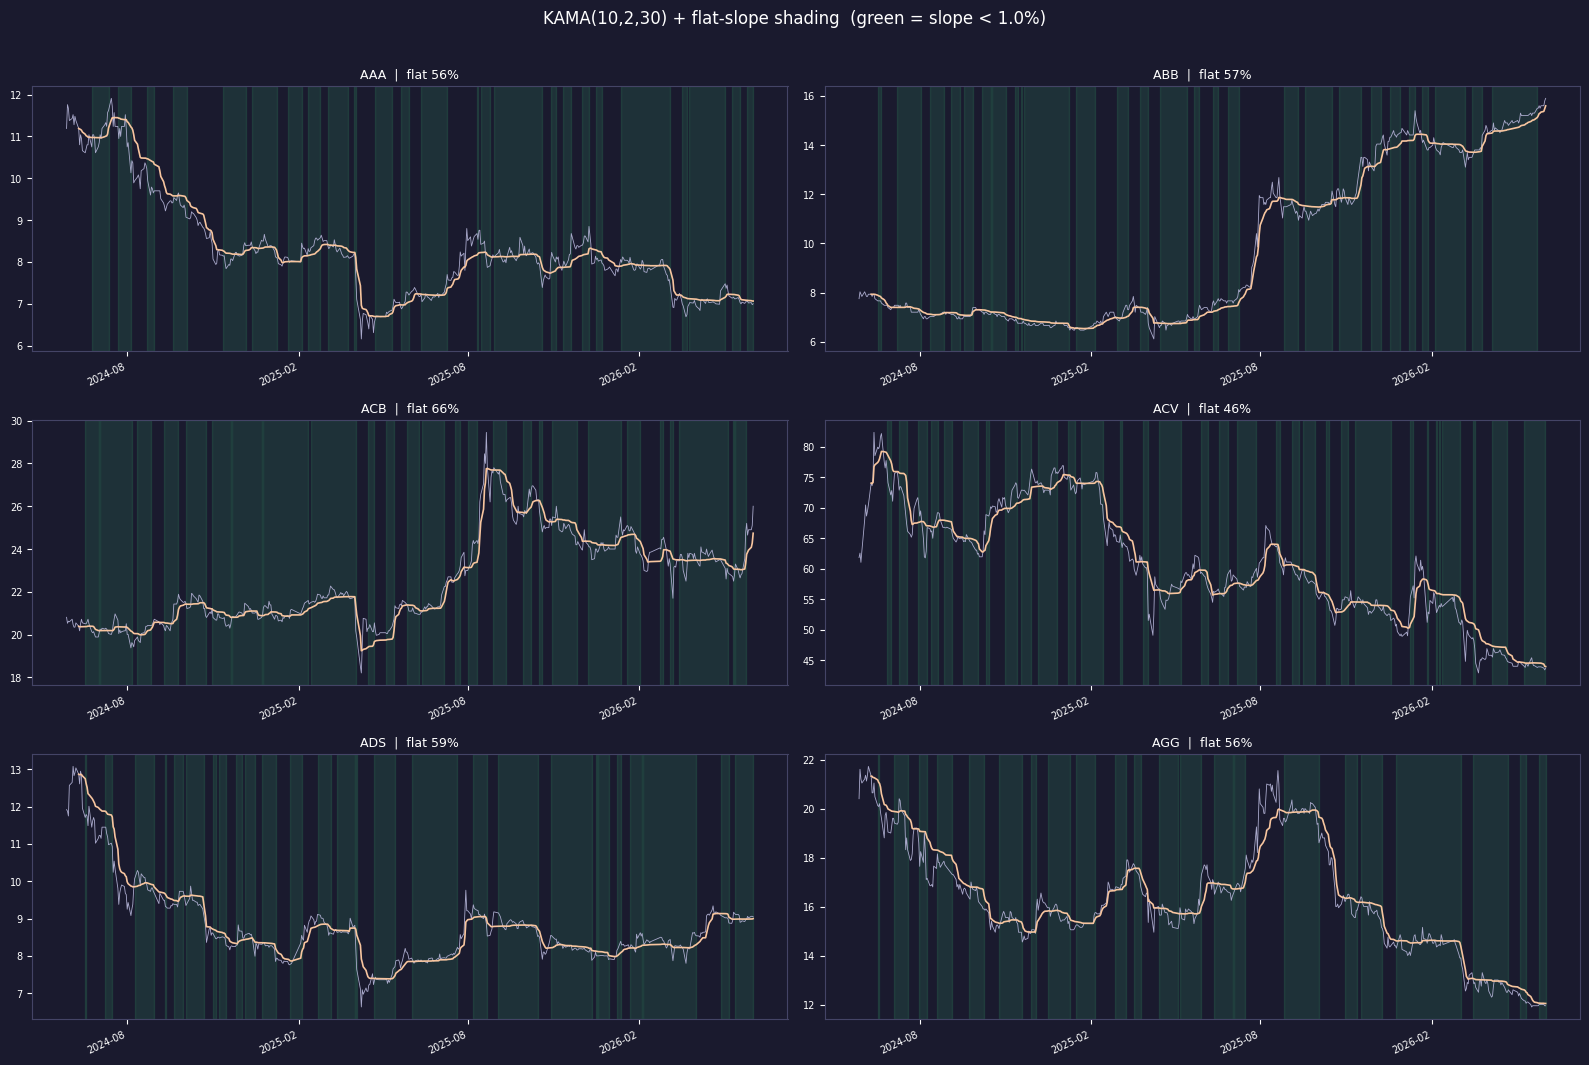

In [37]:
# ── Multi-Symbol KAMA Grid ────────────────────────────────────────────────────
# Shows KAMA + flat shading for up to N_GRID symbols in a grid layout.

N_GRID      = 6          # symbols to display
GRID_SYMS   = close.columns[:N_GRID].tolist()   # or specify: ['ACB','VCB',...]
KAMA_PERIOD = 10
KAMA_FAST   = 2
KAMA_SLOW   = 30
SLOPE_WIN   = 5
FLAT_PCT    = 1.0
LOOKBACK    = 504        # bars to show (None = all)

ncols = 2
nrows = (len(GRID_SYMS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes = axes.flatten() if nrows * ncols > 1 else [axes]
fig.patch.set_facecolor('#1a1a2e')

for ax, sym in zip(axes, GRID_SYMS):
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white', labelsize=7)

    c1d = close[[sym]].to_numpy().astype(np.float64)
    if LOOKBACK:
        c1d = c1d[-LOOKBACK:]
    idx_s = close.index[-len(c1d):]

    kama_s = kama_2d(c1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
    flat_s = slope_flat_2d(kama_s, SLOPE_WIN, FLAT_PCT)[:, 0]

    # shade flat regions (vectorised)
    changes = np.where(np.diff(flat_s.astype(int)) != 0)[0] + 1
    bounds  = [0] + list(changes) + [len(flat_s)]
    for s, e in zip(bounds[:-1], bounds[1:]):
        if flat_s[s]:
            ax.axvspan(idx_s[s], idx_s[min(e, len(idx_s)-1)],
                       color='#3ddc84', alpha=0.12)

    ax.plot(idx_s, c1d[:, 0],     color='#aaaacc', lw=0.6)
    ax.plot(idx_s, kama_s[:, 0],  color='#f7c59f', lw=1.2)

    flat_pct = flat_s.mean() * 100
    ax.set_title(f'{sym}  |  flat {flat_pct:.0f}%', color='white', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

# Hide unused axes
for ax in axes[len(GRID_SYMS):]:
    ax.set_visible(False)

fig.suptitle(
    f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW}) + flat-slope shading  '
    f'(green = slope < {FLAT_PCT}%)',
    color='white', fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# Smart Money Flow Cloud [BOSWaves] — Python port of the Pine Script indicator
# ══════════════════════════════════════════════════════════════════════════════

def _alma_1d(series: np.ndarray, period: int, offset: float, sigma: float) -> np.ndarray:
    """Arnaud Legoux Moving Average (1-D numpy)."""
    m = offset * (period - 1)
    s = period / sigma
    w = np.exp(-((np.arange(period) - m) ** 2) / (2 * s * s))
    w /= w.sum()
    out = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        out[i] = np.dot(w, series[i - period + 1 : i + 1])
    return out


def smart_money_flow_cloud(
    open_df: pd.DataFrame,
    high_df: pd.DataFrame,
    low_df:  pd.DataFrame,
    close_df:pd.DataFrame,
    vol_df:  pd.DataFrame,
    # Core trend
    trend_len:    int   = 34,
    basis_type:   str   = 'EMA',   # 'EMA' | 'ALMA'
    alma_offset:  float = 0.85,
    alma_sigma:   float = 6.0,
    basis_smooth: int   = 3,
    # Smart Money Flow
    mf_len:    int   = 24,
    mf_smooth: int   = 5,
    mf_power:  float = 1.2,
    # Adaptive bands
    atr_len:  int   = 14,
    min_mult: float = 0.9,
    max_mult: float = 2.2,
    # Retest dot cooldown
    dot_cooldown: int = 12,
) -> dict:
    """
    Python port of Smart Money Flow Cloud [BOSWaves].

    Returns a dict of DataFrames (same shape as inputs):
      b_open, b_close       — basis cloud lines
      upper, lower          — adaptive bands
      mf_smooth             — normalised smart money flow  [-1, 1]
      strength              — flow strength                [0, 1]
      mult                  — adaptive ATR multiplier
      last_signal           — 1 = bull, -1 = bear (state machine)
      switch_up/down        — buy/sell signal bars
      bull_dot/bear_dot     — retest dots (with cooldown)
      strength_signed       — tanh-scaled trend strength  [-1, 1]
    """
    results = {}
    syms = close_df.columns

    for sym in syms:
        o = open_df[sym].values.astype(np.float64)
        h = high_df[sym].values.astype(np.float64)
        l = low_df[sym].values.astype(np.float64)
        c = close_df[sym].values.astype(np.float64)
        v = vol_df[sym].values.astype(np.float64)
        n = len(c)
        idx = close_df.index

        # ── Basis ────────────────────────────────────────────────────────────
        if basis_type == 'ALMA':
            raw_o = _alma_1d(o, trend_len, alma_offset, alma_sigma)
            raw_c = _alma_1d(c, trend_len, alma_offset, alma_sigma)
        else:
            raw_o = pd.Series(o, index=idx).ewm(span=trend_len, adjust=False).mean().values
            raw_c = pd.Series(c, index=idx).ewm(span=trend_len, adjust=False).mean().values

        if basis_smooth > 1:
            b_o = pd.Series(raw_o, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
            b_c = pd.Series(raw_c, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
        else:
            b_o, b_c = raw_o, raw_c

        b_main = b_c

        # ── Smart Money Flow ─────────────────────────────────────────────────
        hl = h - l
        clv = np.where(hl == 0, 0.0, ((c - l) - (h - c)) / hl)
        raw_flow = clv * v

        mf_num = pd.Series(raw_flow, index=idx).rolling(mf_len).sum().values
        mf_den = pd.Series(np.abs(raw_flow), index=idx).rolling(mf_len).sum().values
        mf_raw = np.where(mf_den == 0, 0.0, mf_num / mf_den)

        mf_sm = (pd.Series(mf_raw, index=idx).ewm(span=mf_smooth, adjust=False).mean().values
                 if mf_smooth > 1 else mf_raw)

        strength = np.clip(np.power(np.abs(mf_sm), mf_power), 0.0, 1.0)
        mult     = min_mult + (max_mult - min_mult) * strength

        # ── Adaptive bands ───────────────────────────────────────────────────
        atr    = talib.ATR(h, l, c, timeperiod=atr_len)
        upper  = b_main + atr * mult
        lower  = b_main - atr * mult

        # ── Signal state machine ─────────────────────────────────────────────
        long_cond  = (np.roll(c, 1) <= np.roll(upper, 1)) & (c > upper)
        short_cond = (np.roll(c, 1) >= np.roll(lower, 1)) & (c < lower)
        long_cond[0] = short_cond[0] = False

        last_sig = np.zeros(n, dtype=np.int8)
        last_sig[0] = 1 if c[0] >= b_main[0] else -1
        for i in range(1, n):
            if long_cond[i]:   last_sig[i] =  1
            elif short_cond[i]:last_sig[i] = -1
            else:               last_sig[i] = last_sig[i - 1]

        switch_up   = (last_sig ==  1) & (np.roll(last_sig, 1) == -1)
        switch_down = (last_sig == -1) & (np.roll(last_sig, 1) ==  1)
        switch_up[0] = switch_down[0] = False

        # ── Retest dots with cooldown ────────────────────────────────────────
        bear_cond = (last_sig == -1) & (h > b_c)
        bull_cond = (last_sig ==  1) & (l < b_c)
        bear_dot  = np.zeros(n, dtype=bool)
        bull_dot  = np.zeros(n, dtype=bool)
        last_bear = last_bull = -dot_cooldown - 1
        for i in range(n):
            if bear_cond[i] and (dot_cooldown == 0 or i - last_bear >= dot_cooldown):
                bear_dot[i] = True; last_bear = i
            if bull_cond[i] and (dot_cooldown == 0 or i - last_bull >= dot_cooldown):
                bull_dot[i] = True; last_bull = i

        # ── Trend strength (tanh-scaled) ─────────────────────────────────────
        mintick = 0.01
        up_span = np.maximum(upper - b_main, mintick)
        dn_span = np.maximum(b_main - lower, mintick)
        raw_str = np.where(last_sig == 1,
                           (c - b_main) / up_span,
                           -(b_main - c) / dn_span)
        x = np.clip(raw_str * 1.5, -10, 10)
        v_tanh = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
        str_signed = pd.Series(v_tanh, index=idx).ewm(span=3, adjust=False).mean().values

        results[sym] = {
            'b_open':         pd.Series(b_o,         index=idx),
            'b_close':        pd.Series(b_c,         index=idx),
            'upper':          pd.Series(upper,        index=idx),
            'lower':          pd.Series(lower,        index=idx),
            'mf_smooth':      pd.Series(mf_sm,        index=idx),
            'strength':       pd.Series(strength,     index=idx),
            'mult':           pd.Series(mult,         index=idx),
            'last_signal':    pd.Series(last_sig,     index=idx),
            'switch_up':      pd.Series(switch_up,    index=idx),
            'switch_down':    pd.Series(switch_down,  index=idx),
            'bull_dot':       pd.Series(bull_dot,     index=idx),
            'bear_dot':       pd.Series(bear_dot,     index=idx),
            'strength_signed':pd.Series(str_signed,   index=idx),
        }

    return results


print('smart_money_flow_cloud() defined')


smart_money_flow_cloud() defined


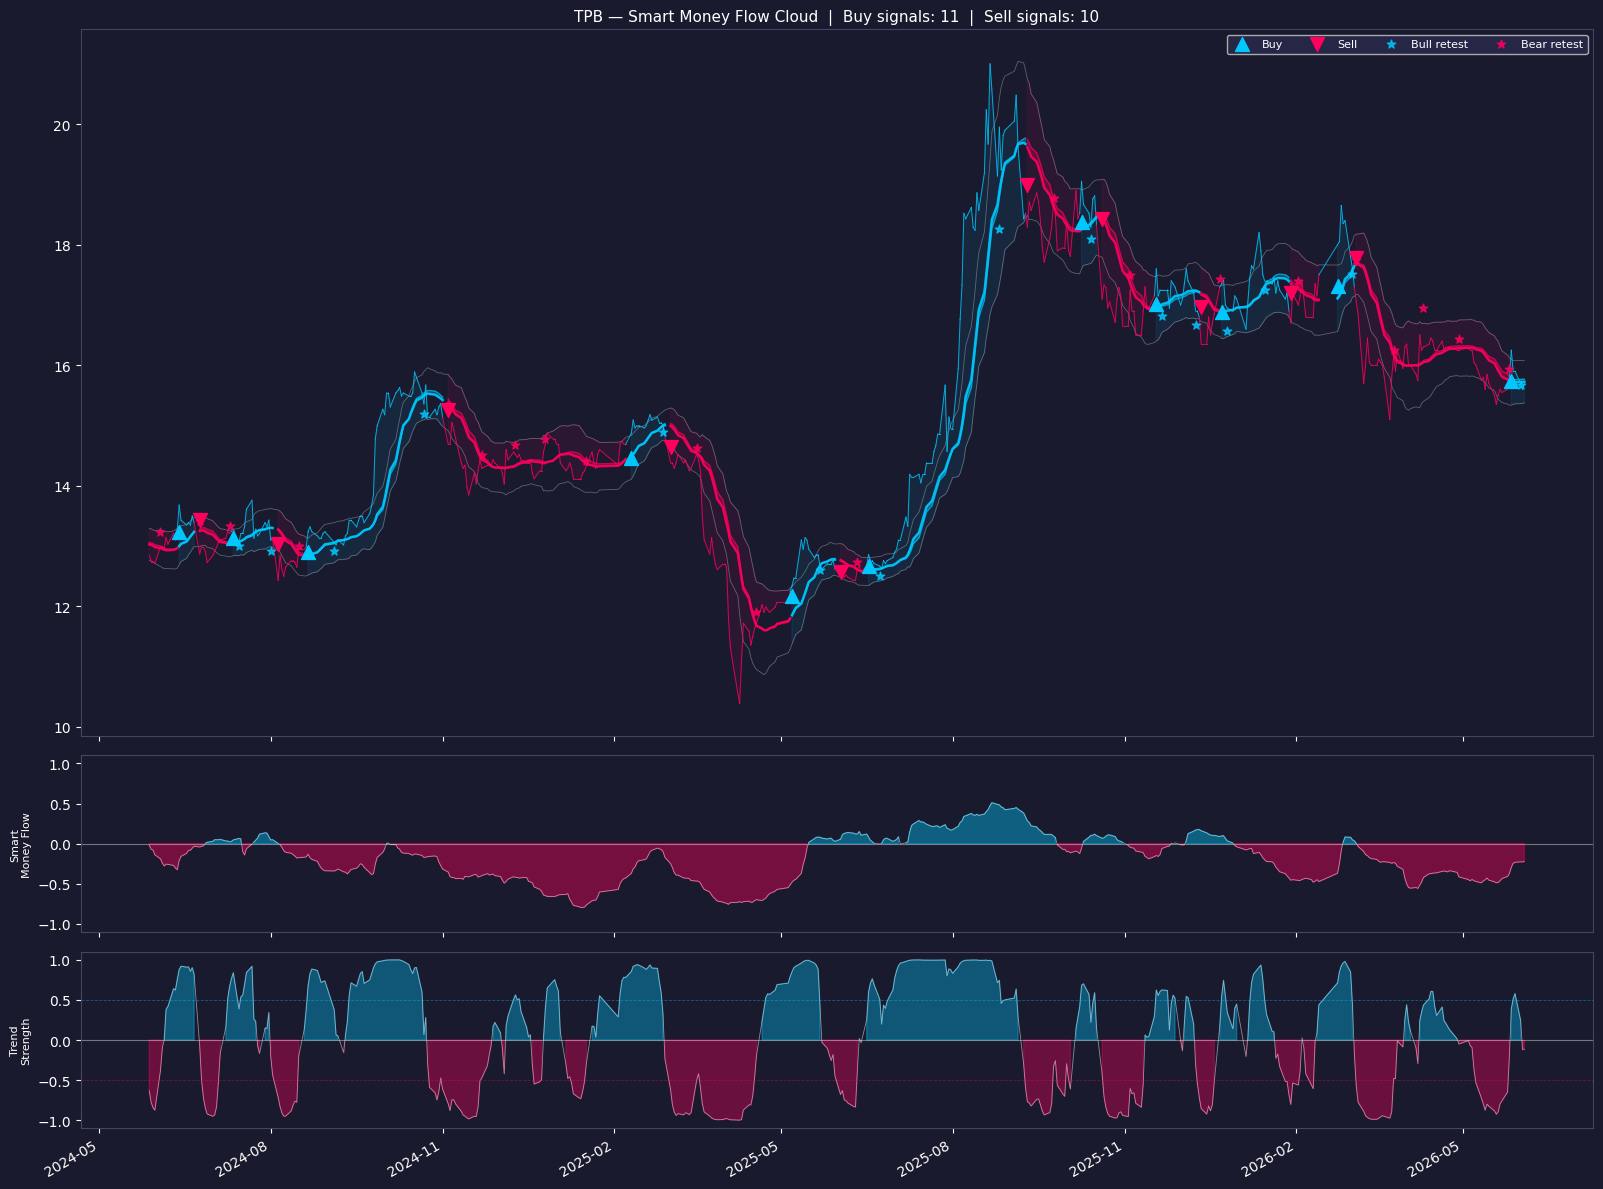


TPB — Latest readings:
  Regime   : BULL 🟢
  MF Flow  : -0.224
  Strength : 16.6%
  Band mult: 1.12x
  Upper    : 16.08  |  Lower: 15.38
  Trend str: -0.114
  Last trade date: 2026-06-03 00:00:00


In [39]:
def plot_smart_money_flow_cloud(
    open_, high, low, close, volume,
    sym='PAN',
    trend_len=34,
    basis_type='EMA',
    basis_smooth=3,
    mf_len=24,
    mf_smooth=5,
    mf_power=1.2,
    atr_len=14,
    min_mult=0.9,
    max_mult=2.2,
    dot_cooldown=12,
    lookback=504,
):
    """Smart Money Flow Cloud — price cloud, MF flow, and trend strength panels."""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import warnings
    warnings.filterwarnings("ignore")

    _res = smart_money_flow_cloud(
        open_[[sym]], high[[sym]], low[[sym]],
        close[[sym]], volume[[sym]],
        trend_len=trend_len, basis_type=basis_type, basis_smooth=basis_smooth,
        mf_len=mf_len, mf_smooth=mf_smooth, mf_power=mf_power,
        atr_len=atr_len, min_mult=min_mult, max_mult=max_mult,
        dot_cooldown=dot_cooldown,
    )[sym]

    if lookback:
        sl = slice(-lookback, None)
        _r = {k: v.iloc[sl] for k, v in _res.items()}
        _c = close[sym].iloc[sl]
        _h = high[sym].iloc[sl]
        _l = low[sym].iloc[sl]
    else:
        _r = _res
        _c = close[sym]
        _h = high[sym]
        _l = low[sym]

    idx = _c.index
    sig = _r['last_signal'].values
    BULL_C, BEAR_C = '#00C8FF', '#FF005D'
    DARK = '#1a1a2e'

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
        gridspec_kw={'height_ratios': [4, 1, 1]})
    fig.patch.set_facecolor(DARK)
    for ax in (ax1, ax2, ax3):
        ax.set_facecolor(DARK)
        for sp in ax.spines.values():
            sp.set_color('#444466')
        ax.tick_params(colors='white')

    bull_mask = sig == 1
    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        ax1.fill_between(idx, _r['b_open'], _r['b_close'],
                         where=mask, color=color, alpha=0.25, label='_')

    above_lower = _c.values > _r['lower'].values
    below_upper = _c.values < _r['upper'].values
    ax1.fill_between(idx, _c, _r['lower'],
                     where=bull_mask & above_lower, color=BULL_C, alpha=0.08)
    ax1.fill_between(idx, _c, _r['upper'],
                     where=(~bull_mask) & below_upper, color=BEAR_C, alpha=0.08)

    ax1.plot(idx, _r['upper'], color='white', lw=0.6, alpha=0.3)
    ax1.plot(idx, _r['lower'], color='white', lw=0.6, alpha=0.3)

    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        masked_c = np.where(mask, _r['b_close'].values, np.nan)
        masked_o = np.where(mask, _r['b_open'].values, np.nan)
        ax1.plot(idx, masked_c, color=color, lw=1.8, alpha=0.9)
        ax1.plot(idx, masked_o, color=color, lw=1.0, alpha=0.6)

    for i in range(1, len(idx)):
        c = BULL_C if sig[i] == 1 else BEAR_C
        ax1.plot(idx[i-1:i+1], _c.values[i-1:i+1], color=c, lw=0.7, alpha=0.8)

    atr_off = (_r['upper'] - _r['lower']).values * 0.08
    up_idx = np.where(_r['switch_up'].values)[0]
    dn_idx = np.where(_r['switch_down'].values)[0]
    ax1.scatter(idx[up_idx], _l.values[up_idx] - atr_off[up_idx],
                marker='^', color=BULL_C, s=100, zorder=6, label='Buy')
    ax1.scatter(idx[dn_idx], _h.values[dn_idx] + atr_off[dn_idx],
                marker='v', color=BEAR_C, s=100, zorder=6, label='Sell')

    bull_d = np.where(_r['bull_dot'].values)[0]
    bear_d = np.where(_r['bear_dot'].values)[0]
    ax1.scatter(idx[bull_d], _l.values[bull_d] - atr_off[bull_d] * 0.5,
                marker='*', color=BULL_C, s=40, alpha=0.8, zorder=5, label='Bull retest')
    ax1.scatter(idx[bear_d], _h.values[bear_d] + atr_off[bear_d] * 0.5,
                marker='*', color=BEAR_C, s=40, alpha=0.8, zorder=5, label='Bear retest')

    n_buy, n_sell = len(up_idx), len(dn_idx)
    ax1.set_title(
        f'{sym} — Smart Money Flow Cloud  |  '
        f'Buy signals: {n_buy}  |  Sell signals: {n_sell}',
        color='white', fontsize=11,
    )
    ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4)

    mf_vals = _r['mf_smooth'].values
    ax2.fill_between(idx, mf_vals, 0, where=mf_vals >= 0, color=BULL_C, alpha=0.4)
    ax2.fill_between(idx, mf_vals, 0, where=mf_vals < 0, color=BEAR_C, alpha=0.4)
    ax2.plot(idx, mf_vals, color='white', lw=0.6, alpha=0.5)
    ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax2.set_ylabel('Smart\nMoney Flow', color='white', fontsize=8)
    ax2.set_ylim(-1.1, 1.1)

    str_vals = _r['strength_signed'].values
    ax3.fill_between(idx, str_vals, 0, where=str_vals >= 0, color=BULL_C, alpha=0.35)
    ax3.fill_between(idx, str_vals, 0, where=str_vals < 0, color=BEAR_C, alpha=0.35)
    ax3.plot(idx, str_vals, color='white', lw=0.6, alpha=0.5)
    ax3.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax3.axhline(0.5, color=BULL_C, lw=0.6, ls='--', alpha=0.4)
    ax3.axhline(-0.5, color=BEAR_C, lw=0.6, ls='--', alpha=0.4)
    ax3.set_ylabel('Trend\nStrength', color='white', fontsize=8)
    ax3.set_ylim(-1.1, 1.1)

    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

    plt.tight_layout()
    plt.show()

    cur_sig = "BULL 🟢" if _r['last_signal'].iloc[-1] == 1 else "BEAR 🔴"
    print(f"\n{sym} — Latest readings:")
    print(f"  Regime   : {cur_sig}")
    print(f"  MF Flow  : {_r['mf_smooth'].iloc[-1]:+.3f}")
    print(f"  Strength : {_r['strength'].iloc[-1]:.1%}")
    print(f"  Band mult: {_r['mult'].iloc[-1]:.2f}x")
    print(f"  Upper    : {_r['upper'].iloc[-1]:,.2f}  |  Lower: {_r['lower'].iloc[-1]:,.2f}")
    print(f"  Trend str: {_r['strength_signed'].iloc[-1]:+.3f}")
    print(f"  Last trade date: {idx[-1]}")


# ── Config & run ──────────────────────────────────────────────────────────────
plot_smart_money_flow_cloud(
    open_, high, low, close, volume,
    sym='TPB',
    trend_len=34,
    basis_type='ALMA',        # 'EMA' | 'ALMA'
    basis_smooth=3,
    mf_len=24, mf_smooth=5, mf_power=1.2,
    atr_len=14, min_mult=0.9, max_mult=2.2, dot_cooldown=12,
    lookback=504,              # bars to show (None = all)
)
